In [1]:
#Transformer code i.e. only giving all frames of reconstruction

In [ ]:
#Transformer Code that outputs multiple reconstructed text files with generated skeleton plots.
#These reconstructed text files will not be used, we have separate code for reconstructed text files in next section
# --- Imports ---
import numpy as np
import tensorflow as tf
import os
import matplotlib.pyplot as plt
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Input, Dense, Dropout, LayerNormalization,
                                     MultiHeadAttention, Reshape, Flatten, Concatenate, Conv1D)
from sklearn.model_selection import train_test_split
import pandas as pd
from scipy.interpolate import interp1d

# --- Parameters ---
Tm = 30  # Temporal length (number of frames)
NUM_JOINTS = 20
JOINT_DIM = 3
LAMBDA = 100
LAMBDA_BONE = 10
LAMBDA_TEMPORAL = 5
BATCH_SIZE = 10
BONES = [
    (0, 1), (1, 2), (2, 3), (2, 4), (4, 5), (5, 6), (6, 7),
    (2, 8), (8, 9), (9, 10), (10, 11),
    (0, 12), (12, 13), (13, 14), (14, 15),
    (0, 16), (16, 17), (17, 18), (18, 19)
]

# --- Positional Encoding Layer ---
class PositionalEncoding(tf.keras.layers.Layer):
    def __init__(self, d_model, max_len=500):
        super().__init__()
        pos = tf.cast(tf.range(max_len)[:, tf.newaxis], tf.float32)
        i = tf.cast(tf.range(d_model)[tf.newaxis, :], tf.float32)
        angle_rates = 1.0 / tf.pow(10000.0, (2 * (i // 2)) / d_model)
        angle_rads = pos * angle_rates
        sines = tf.math.sin(angle_rads[:, 0::2])
        cosines = tf.math.cos(angle_rads[:, 1::2])
        pos_encoding = tf.concat([sines, cosines], axis=-1)
        self.pos_encoding = pos_encoding[tf.newaxis, ...]

    def call(self, x):
        return x + self.pos_encoding[:, :tf.shape(x)[1], :]

# --- Transformer Encoder Layer ---
def transformer_encoder_layer(embed_dim, num_heads, ff_dim, rate=0.1):
    inputs = Input(shape=(None, embed_dim))
    attention = MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)(inputs, inputs)
    attention = Dropout(rate)(attention)
    out1 = LayerNormalization(epsilon=1e-6)(inputs + attention)
    ffn = Dense(ff_dim, activation='relu')(out1)
    ffn = Dense(embed_dim)(ffn)
    ffn = Dropout(rate)(ffn)
    out2 = LayerNormalization(epsilon=1e-6)(out1 + ffn)
    return Model(inputs, out2)

# --- Transformer-based Generator ---
def build_transformer_generator(Tm, NUM_JOINTS, JOINT_DIM, embed_dim=256, ff_dim=512, num_heads=8, num_layers=6):
    input_shape = (Tm, NUM_JOINTS * JOINT_DIM)
    inputs = Input(shape=input_shape)
    x = Dense(embed_dim)(inputs)
    x = PositionalEncoding(embed_dim)(x)
    for _ in range(num_layers):
        x = transformer_encoder_layer(embed_dim, num_heads, ff_dim)(x)
    x = Conv1D(filters=embed_dim, kernel_size=3, padding='same', activation='relu')(x)
    x = Dense(NUM_JOINTS * JOINT_DIM)(x)
    outputs = Reshape((Tm, NUM_JOINTS, JOINT_DIM))(x)
    return Model(inputs, outputs, name="TransformerGenerator")

# --- PatchGAN Discriminator ---
def build_discriminator():
    real_in = Input(shape=(Tm, NUM_JOINTS, JOINT_DIM))
    gen_in = Input(shape=(Tm, NUM_JOINTS, JOINT_DIM))
    x_real = Flatten()(real_in)
    x_gen = Flatten()(gen_in)
    x = Concatenate()([x_real, x_gen])
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.3)(x)
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.3)(x)
    x = Dense(1, activation='sigmoid')(x)
    return Model([real_in, gen_in], x, name="Discriminator")

# --- Custom Combined Loss ---
def combined_loss(real, gen):
    mae_loss = tf.reduce_mean(tf.abs(real - gen))
    bone_loss = bone_length_loss(real, gen)
    temp_loss = temporal_smoothness_loss(real, gen)
    return LAMBDA * mae_loss + LAMBDA_BONE * bone_loss + LAMBDA_TEMPORAL * temp_loss

# --- GAN Model ---
def build_gan(generator, discriminator):
    discriminator.trainable = False
    occluded_input = Input(shape=(Tm, NUM_JOINTS, JOINT_DIM))
    real_input = Input(shape=(Tm, NUM_JOINTS, JOINT_DIM))
    flatten_input = Reshape((Tm, NUM_JOINTS * JOINT_DIM))(occluded_input)
    gen_out = generator(flatten_input)
    validity = discriminator([real_input, gen_out])
    model = Model([occluded_input, real_input], [validity, gen_out], name="GAN")
    discriminator.trainable = True
    return model

# --- Bone Length Loss ---
def bone_length_loss(real, gen):
    loss = 0
    for a, b in BONES:
        real_len = tf.norm(real[:, :, a] - real[:, :, b], axis=-1)
        gen_len = tf.norm(gen[:, :, a] - gen[:, :, b], axis=-1)
        loss += tf.reduce_mean(tf.square(real_len - gen_len))
    return loss

# --- Temporal Smoothness Loss ---
def temporal_smoothness_loss(real, gen):
    return tf.reduce_mean(tf.square((real[:,1:] - real[:,:-1]) - (gen[:,1:] - gen[:,:-1])))

# --- Load and Pad Skeleton File ---
def interpolate_to_fixed_length(data, target_length):
    x_old = np.linspace(0, 1, len(data))
    x_new = np.linspace(0, 1, target_length)
    f = interp1d(x_old, data, axis=0, kind='linear', fill_value="extrapolate")
    return f(x_new)

def load_and_pad_file(file_path, Tm=30, num_joints=20, joint_dim=3):
    data = np.loadtxt(file_path)
    joint_data = data[:, 1:]
    if joint_data.shape[0] < Tm:
        joint_data = interpolate_to_fixed_length(joint_data, Tm)
    else:
        joint_data = joint_data[:Tm]
    return joint_data.reshape((Tm, num_joints, joint_dim))

# --- 2D Skeleton Visualization ---
def visualize_skeletons(real, occluded, generated, title):
    fig, axs = plt.subplots(1, 3, figsize=(15, 5))
    datasets = [real, occluded, generated]
    titles = ['Real', 'Occluded', 'Generated']

    for i, data in enumerate(datasets):
        axs[i].set_title(titles[i])
        #axs[i].invert_yaxis()
        axs[i].set_aspect('equal')
        axs[i].axis('off')
        for a, b in BONES:
            axs[i].plot([data[a, 0], data[b, 0]], [data[a, 1], data[b, 1]], 'ro-')

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

# --- Dataset Split and Evaluation Helper ---
def split_and_evaluate(real_seqs, occluded_seqs, generator):
    X_train, X_temp, y_train, y_temp = train_test_split(occluded_seqs, real_seqs, test_size=0.2, random_state=42)
    X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

    def weighted_accuracy(y_true, y_pred):
        diff = np.abs(y_true - y_pred)
        norm = np.abs(y_true) + 1e-6
        acc = 1 - (diff / norm)
        acc = np.clip(acc, 0, 1)
        return np.mean(acc)

    def joint_wise_mse(y_true, y_pred):
        errors = np.mean((y_true - y_pred) ** 2, axis=(0, 1))
        return errors.reshape((NUM_JOINTS, JOINT_DIM))

    def evaluate(name, X, y):
        pred = generator.predict(X.reshape((X.shape[0], Tm, NUM_JOINTS * JOINT_DIM)))
        mse = np.mean((y - pred) ** 2)
        mae = np.mean(np.abs(y - pred))
        wacc = weighted_accuracy(y, pred)
        joint_errors = joint_wise_mse(y, pred)
        visualize_skeletons(y[0, -1], X[0, -1], pred[0, -1], f"{name} Sample (Last Frame)")
        print(f"Joint-wise MSE ({name}):\n", joint_errors)
        return {"Set": name, "MSE": mse, "MAE": mae, "WAcc": wacc}

    return pd.DataFrame([
        evaluate("Train", X_train, y_train),
        evaluate("Val", X_val, y_val),
        evaluate("Test", X_test, y_test)
    ])

# --- Main Driver ---
if __name__ == "__main__":
    case_dirs = [
        "right_arm", "left_arm", "right_leg", "left_leg",
        "right_arm_leg", "left_arm_leg", "both_arms", "both_legs"
    ]
    base_real_path = "D:/Thesis/DATA/joints1/joints"  # CHANGE to actual path
    base_occ_path = "D:/Thesis/DATA/joints1/occluded_txt"  # CHANGE to actual path
    
    all_eval = []
    for case in case_dirs:
        print(f"Training and evaluating for occlusion case: {case}")
        generator = build_transformer_generator(Tm, NUM_JOINTS, JOINT_DIM)
        discriminator = build_discriminator()
        gan = build_gan(generator, discriminator)

        case_path = os.path.join(base_occ_path, case)
        real_files = [load_and_pad_file(os.path.join(base_real_path, f), Tm, NUM_JOINTS, JOINT_DIM) for f in os.listdir(base_real_path)]
        occ_files = [load_and_pad_file(os.path.join(case_path, f), Tm, NUM_JOINTS, JOINT_DIM) for f in os.listdir(case_path)]

        real_data = np.stack(real_files)
        occluded_data = np.stack(occ_files)

        gan.compile(
            loss=["binary_crossentropy", combined_loss],
            loss_weights=[1.0, 1.0],
            optimizer=tf.keras.optimizers.Adam(0.001)
        )

        dummy_y = np.ones((real_data.shape[0], 1))
        gan.fit([occluded_data, real_data], [dummy_y, real_data], epochs=50, batch_size=BATCH_SIZE)

        df = split_and_evaluate(real_data, occluded_data, generator)
        df["Case"] = case
        all_eval.append(df)

    result_table = pd.concat(all_eval).pivot(index="Case", columns="Set", values=["MSE", "MAE", "WAcc"])
    print(result_table.round(6))


In [1]:
# Transformer-based Skeleton Reconstruction (Variable-Length Version)
# Each reconstructed text file keeps same frame count as its input file
#This will produce the reconstruted files only which will further be used in Activites classification

import numpy as np
import tensorflow as tf
import os
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Dense, Dropout, LayerNormalization,
    MultiHeadAttention, Reshape, Conv1D
)
from scipy.interpolate import interp1d

# --- Parameters ---
NUM_JOINTS = 20
JOINT_DIM = 3
LAMBDA = 100
LAMBDA_BONE = 10
LAMBDA_TEMPORAL = 5
BATCH_SIZE = 10
BONES = [
    (0, 1), (1, 2), (2, 3), (2, 4), (4, 5), (5, 6), (6, 7),
    (2, 8), (8, 9), (9, 10), (10, 11),
    (0, 12), (12, 13), (13, 14), (14, 15),
    (0, 16), (16, 17), (17, 18), (18, 19)
]

# --- Positional Encoding ---
class PositionalEncoding(tf.keras.layers.Layer):
    def __init__(self, d_model):
        super().__init__()
        self.d_model = int(d_model)

    def call(self, x):
        # x shape: (batch, seq_len, d_model)
        seq_len = tf.shape(x)[1]
        d_model = self.d_model

        pos = tf.cast(tf.range(seq_len)[:, tf.newaxis], tf.float32)            # (seq_len, 1)
        i = tf.cast(tf.range(d_model)[tf.newaxis, :], tf.float32)             # (1, d_model)
        angle_rates = 1.0 / tf.pow(10000.0, (2 * (i // 2)) / tf.cast(d_model, tf.float32))
        angle_rads = pos * angle_rates                                        # (seq_len, d_model)

        sines = tf.sin(angle_rads[:, 0::2])
        cosines = tf.cos(angle_rads[:, 1::2])

        # interleave sines and cosines to form (seq_len, d_model)
        pos_encoding = tf.reshape(
            tf.concat([tf.expand_dims(sines, -1), tf.expand_dims(cosines, -1)], axis=-1),
            (seq_len, d_model)
        )

        pos_encoding = pos_encoding[tf.newaxis, ...]  # (1, seq_len, d_model)
        return x + tf.cast(pos_encoding, x.dtype)

# --- Transformer Encoder Layer ---
def transformer_encoder_layer(embed_dim, num_heads, ff_dim, rate=0.1):
    inputs = Input(shape=(None, embed_dim))
    attention = MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)(inputs, inputs)
    attention = Dropout(rate)(attention)
    out1 = LayerNormalization(epsilon=1e-6)(inputs + attention)
    ffn = Dense(ff_dim, activation='relu')(out1)
    ffn = Dense(embed_dim)(ffn)
    ffn = Dropout(rate)(ffn)
    out2 = LayerNormalization(epsilon=1e-6)(out1 + ffn)
    return Model(inputs, out2)

# --- Transformer Generator ---
def build_transformer_generator(NUM_JOINTS, JOINT_DIM, embed_dim=256, ff_dim=512, num_heads=8, num_layers=6):
    inputs = Input(shape=(None, NUM_JOINTS * JOINT_DIM))
    x = Dense(embed_dim)(inputs)
    x = PositionalEncoding(embed_dim)(x)
    for _ in range(num_layers):
        x = transformer_encoder_layer(embed_dim, num_heads, ff_dim)(x)
    x = Conv1D(filters=embed_dim, kernel_size=3, padding='same', activation='relu')(x)
    x = Dense(NUM_JOINTS * JOINT_DIM)(x)
    outputs = Reshape((-1, NUM_JOINTS, JOINT_DIM))(x)
    return Model(inputs, outputs, name="TransformerGenerator")

# --- Loss Functions ---
def bone_length_loss(real, gen):
    loss = 0
    for a, b in BONES:
        real_len = tf.norm(real[:, :, a] - real[:, :, b], axis=-1)
        gen_len = tf.norm(gen[:, :, a] - gen[:, :, b], axis=-1)
        loss += tf.reduce_mean(tf.square(real_len - gen_len))
    return loss

def temporal_smoothness_loss(real, gen):
    return tf.reduce_mean(tf.square((real[:, 1:] - real[:, :-1]) - (gen[:, 1:] - gen[:, :-1])))

def combined_loss(real, gen):
    mae_loss = tf.reduce_mean(tf.abs(real - gen))
    bone_loss = bone_length_loss(real, gen)
    temp_loss = temporal_smoothness_loss(real, gen)
    return LAMBDA * mae_loss + LAMBDA_BONE * bone_loss + LAMBDA_TEMPORAL * temp_loss

# --- File Loader ---
def load_skeleton_file(file_path, num_joints=20, joint_dim=3):
    data = np.loadtxt(file_path)
    frames = data[:, 1:]  # skip frame index
    n_frames = frames.shape[0]
    return frames.reshape((n_frames, num_joints, joint_dim))

# --- Main ---
if __name__ == "__main__":
    case_dirs = [
        "right_arm", "left_arm", "right_leg", "left_leg",
        "right_arm_leg", "left_arm_leg", "both_arms", "both_legs"
    ]

    base_real_path = "D:/Thesis/DATA/joints1/joints"
    base_occ_path = "D:/Thesis/DATA/joints1/occluded_txt"
    output_dir = "E:/PAPER Codes and research/Reconstruction_Text_files"
    protocol = "transformer"
    

    for case in case_dirs:
        print(f"\n🔹 Processing occlusion case: {case}")
        generator = build_transformer_generator(NUM_JOINTS, JOINT_DIM)
        generator.compile(optimizer=tf.keras.optimizers.Adam(1e-4), loss='mae')

        case_path = os.path.join(base_occ_path, case)
        real_files = sorted(os.listdir(base_real_path))
        occ_files = sorted(os.listdir(case_path))

        # Align number of files
        n_files = min(len(real_files), len(occ_files))
        real_files = real_files[:n_files]
        occ_files = occ_files[:n_files]

        save_dir = os.path.join(output_dir, protocol, case)
        os.makedirs(save_dir, exist_ok=True)

        # Train and reconstruct each sequence individually
        for i in range(n_files):
            real_path = os.path.join(base_real_path, real_files[i])
            occ_path = os.path.join(case_path, occ_files[i])

            real_seq = load_skeleton_file(real_path)
            occ_seq = load_skeleton_file(occ_path)

            n_frames = occ_seq.shape[0]
            print(f"  ▶ File {i+1}/{n_files}: {occ_files[i]} | {n_frames} frames")

            # Train on this sequence only
            generator.fit(
                occ_seq.reshape((1, n_frames, NUM_JOINTS * JOINT_DIM)),
                real_seq.reshape((1, n_frames, NUM_JOINTS, JOINT_DIM)),
                epochs=30, batch_size=1, verbose=0
            )

            # Predict reconstructed skeleton (same frame count)
            pred = generator.predict(occ_seq.reshape((1, n_frames, NUM_JOINTS * JOINT_DIM)))
            pred = pred[0]  # remove batch dim

            # Save reconstructed text
            frame_nums = np.arange(1, n_frames + 1).reshape(n_frames, 1)
            rec_flat = pred.reshape(n_frames, NUM_JOINTS * JOINT_DIM)
            rec_data = np.hstack([frame_nums, rec_flat])
            output_filename = occ_files[i].replace('.txt', '_reconstructed.txt')
            np.savetxt(os.path.join(save_dir, output_filename), rec_data, fmt='%.6f')

        print(f"✅ Completed reconstruction for case: {case}")



🔹 Processing occlusion case: right_arm

  ▶ File 1/20: joints_s01_e01_right_arm.txt | 560 frames
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 698ms/step
  ▶ File 2/20: joints_s01_e02_right_arm.txt | 644 frames
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 659ms/step
  ▶ File 3/20: joints_s02_e01_right_arm.txt | 597 frames
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 221ms/step
  ▶ File 4/20: joints_s02_e02_right_arm.txt | 756 frames
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 273ms/step
  ▶ File 5/20: joints_s03_e01_right_arm.txt | 763 frames
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 304ms/step
  ▶ File 6/20: joints_s03_e02_right_arm.txt | 875 frames
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 336ms/step
  ▶ File 7/20: joints_s04_e01_right_arm.txt | 544 frames
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 197ms/step
  ▶ File 8/20: joints_s04_e02_right_arm.txt | 1360 frames
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 643ms/step
  ▶ File 9/20: joints_s05_e01_right_arm.txt | 830 frames
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 305ms/step
  ▶ File 10/20: joints_s05_e02_right_arm.txt | 534 frames
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 185ms/st

In [19]:
#Transformer Code
#code for reassigning the frame numbers of reconstructed text files which will matches to the real ones skeleton images files

import os
import numpy as np

# --- User paths ---
real_path = "D:/Thesis/DATA/joints1/joints"   # Folder with real skeleton files
reconstructed_path = "E:/PAPER Codes and research/transformer/both_legs"
output_path = reconstructed_path + "_frame_mapped"  # Output folder

os.makedirs(output_path, exist_ok=True)

# --- Get file list ---
real_files = sorted([f for f in os.listdir(real_path) if f.endswith(".txt")])
recon_files = sorted([f for f in os.listdir(reconstructed_path) if f.endswith(".txt")])

# --- Safety check: ensure same count ---
n_files = min(len(real_files), len(recon_files))
real_files = real_files[:n_files]
recon_files = recon_files[:n_files]

print(f"Processing {n_files} files...")

for i in range(n_files):
    real_file = os.path.join(real_path, real_files[i])
    recon_file = os.path.join(reconstructed_path, recon_files[i])

    real_data = np.loadtxt(real_file)
    recon_data = np.loadtxt(recon_file)

    # Extract frame numbers from real file
    real_frames = real_data[:, 0]

    # If reconstructed has same number of frames, replace directly
    if len(real_frames) == len(recon_data):
        recon_data[:, 0] = real_frames
    else:
        # If mismatch, resample frame indices proportionally
        idx = np.linspace(0, len(real_frames) - 1, len(recon_data)).astype(int)
        recon_data[:, 0] = real_frames[idx]

    # Save updated reconstructed file
    out_file = os.path.join(output_path, recon_files[i])
    np.savetxt(out_file, recon_data, fmt="%.6f")

    print(f"✅ Frame numbers remapped: {recon_files[i]}")

print("\nAll reconstructed files updated successfully.")


Processing 20 files...
✅ Frame numbers remapped: joints_s01_e01_both_legs_reconstructed.txt
✅ Frame numbers remapped: joints_s01_e02_both_legs_reconstructed.txt
✅ Frame numbers remapped: joints_s02_e01_both_legs_reconstructed.txt
✅ Frame numbers remapped: joints_s02_e02_both_legs_reconstructed.txt
✅ Frame numbers remapped: joints_s03_e01_both_legs_reconstructed.txt
✅ Frame numbers remapped: joints_s03_e02_both_legs_reconstructed.txt
✅ Frame numbers remapped: joints_s04_e01_both_legs_reconstructed.txt
✅ Frame numbers remapped: joints_s04_e02_both_legs_reconstructed.txt
✅ Frame numbers remapped: joints_s05_e01_both_legs_reconstructed.txt
✅ Frame numbers remapped: joints_s05_e02_both_legs_reconstructed.txt
✅ Frame numbers remapped: joints_s06_e01_both_legs_reconstructed.txt
✅ Frame numbers remapped: joints_s06_e02_both_legs_reconstructed.txt
✅ Frame numbers remapped: joints_s07_e01_both_legs_reconstructed.txt
✅ Frame numbers remapped: joints_s07_e02_both_legs_reconstructed.txt
✅ Frame num

Real training files: ['joints_s05_e01.txt', 'joints_s03_e02.txt', 'joints_s06_e02.txt', 'joints_s02_e02.txt', 'joints_s10_e01.txt', 'joints_s09_e01.txt', 'joints_s07_e02.txt', 'joints_s02_e01.txt', 'joints_s05_e02.txt', 'joints_s10_e02.txt', 'joints_s03_e01.txt', 'joints_s07_e01.txt', 'joints_s04_e02.txt', 'joints_s06_e01.txt', 'joints_s08_e01.txt', 'joints_s04_e01.txt']
Invalid range for s05_e01: walk, 708, 888
Invalid range for s05_e01: sitDown, 1140, 1238
Invalid range for s05_e01: standUp, 1294, 1394
Invalid range for s05_e01: pickUp, 1482, 1676
Invalid range for s05_e01: carry, 1736, 2064
Invalid range for s05_e01: throw, 3104, 3176
Invalid range for s05_e01: push, 3596, 3632
Invalid range for s05_e01: pull, 3706, 3770
Invalid range for s05_e01: waveHands, 3946, 4352
Invalid range for s05_e01: clapHands, 4522, 4734
Invalid range for s03_e02: pickUp, 848, 1018
Invalid range for s03_e02: carry, 1078, 1192
Invalid range for s03_e02: throw, 1638, 1690
Invalid range for s03_e02: push, 

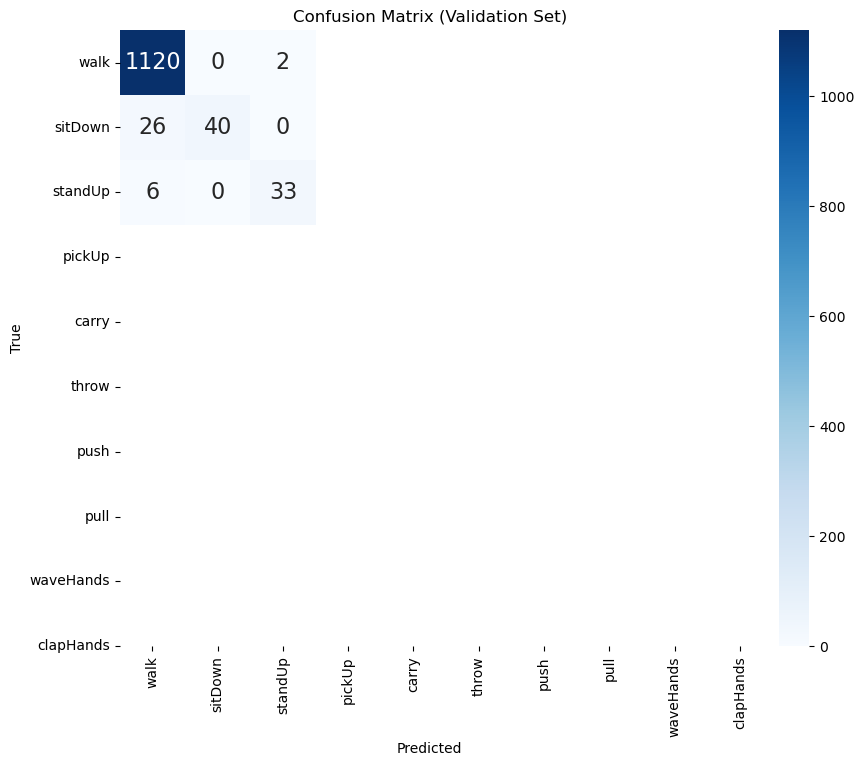


Validation Set Metrics:
              precision    recall  f1-score   support

        walk       0.97      1.00      0.99      1122
     sitDown       1.00      0.61      0.75        66
     standUp       0.94      0.85      0.89        39
      pickUp       0.00      0.00      0.00         0
       carry       0.00      0.00      0.00         0
       throw       0.00      0.00      0.00         0
        push       0.00      0.00      0.00         0
        pull       0.00      0.00      0.00         0
   waveHands       0.00      0.00      0.00         0
   clapHands       0.00      0.00      0.00         0

    accuracy                           0.97      1227
   macro avg       0.29      0.25      0.26      1227
weighted avg       0.97      0.97      0.97      1227



C:\Users\hp\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\hp\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\hp\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\hp\anaconda3\Lib\site-packages\sklearn\me

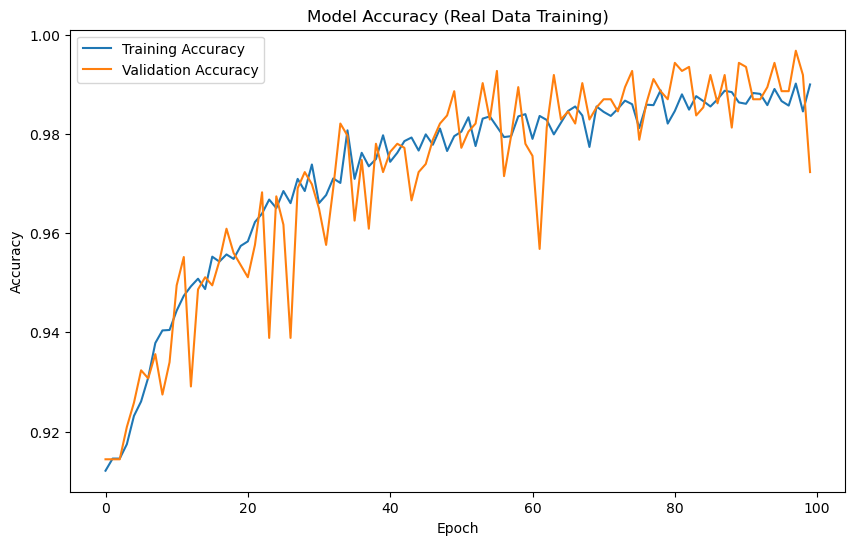


Evaluating classifier on 20% reconstructed data for right_arm
Reconstructed test files for right_arm: ['joints_s01_e01_right_arm_reconstructed.txt', 'joints_s09_e02_right_arm_reconstructed.txt', 'joints_s08_e02_right_arm_reconstructed.txt', 'joints_s01_e02_right_arm_reconstructed.txt', 'joints_s05_e01_right_arm_reconstructed.txt', 'joints_s03_e02_right_arm_reconstructed.txt', 'joints_s06_e02_right_arm_reconstructed.txt', 'joints_s02_e02_right_arm_reconstructed.txt', 'joints_s10_e01_right_arm_reconstructed.txt', 'joints_s09_e01_right_arm_reconstructed.txt', 'joints_s07_e02_right_arm_reconstructed.txt', 'joints_s02_e01_right_arm_reconstructed.txt', 'joints_s05_e02_right_arm_reconstructed.txt', 'joints_s10_e02_right_arm_reconstructed.txt', 'joints_s03_e01_right_arm_reconstructed.txt', 'joints_s07_e01_right_arm_reconstructed.txt']
Invalid range for s01_e01: sitDown, 572, 686
Invalid range for s01_e01: standUp, 704, 752
Invalid range for s01_e01: pickUp, 822, 954
Invalid range for s01_e01:

C:\Users\hp\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Saved confusion matrix for right_arm to C:\Users\hp\Desktop\Transformer_Classification4paper\confusion_matrix_right_arm.png


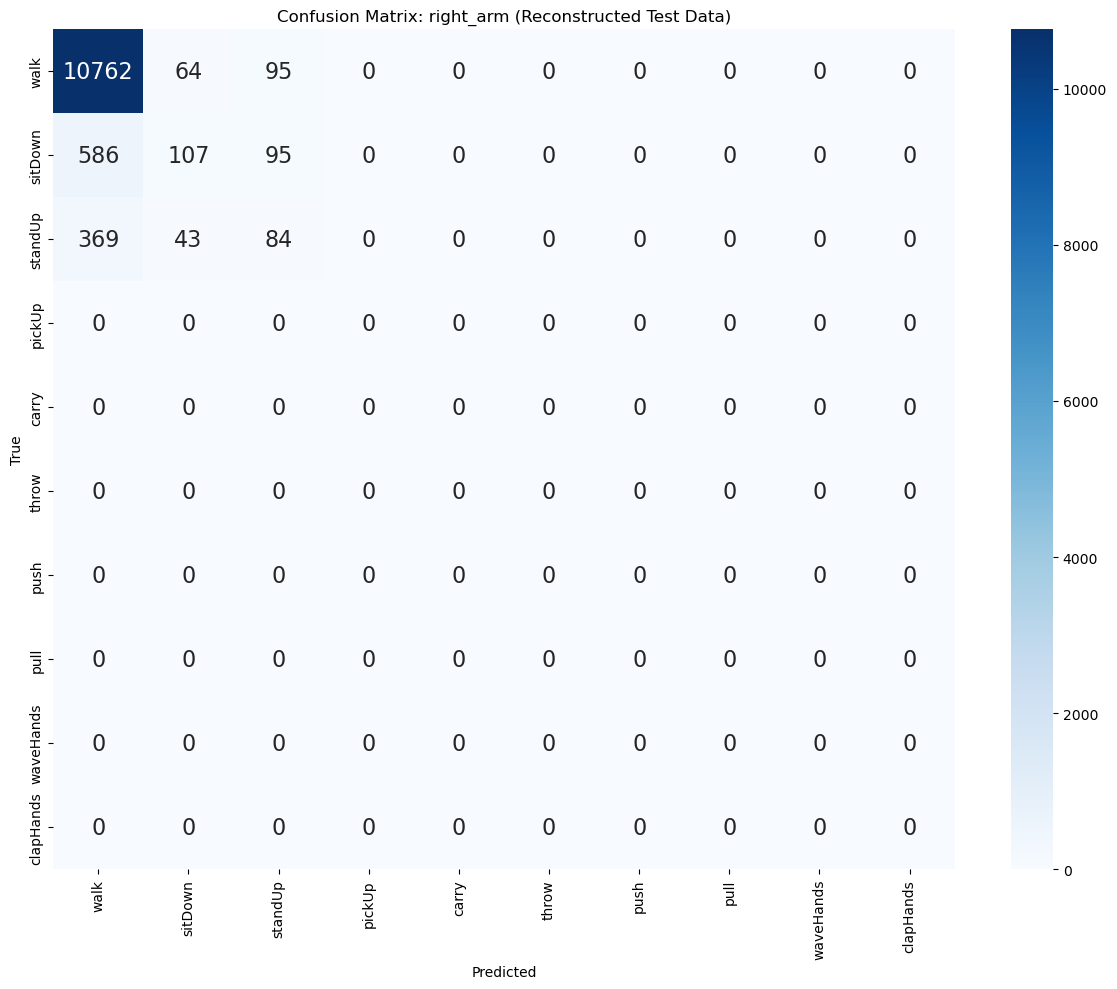


Metrics for right_arm:
Overall Accuracy: 0.8974
Balanced Accuracy: 0.4302
Weighted Accuracy (by support): 0.8974

Evaluating classifier on 20% reconstructed data for left_arm
Reconstructed test files for left_arm: ['joints_s01_e01_left_arm_reconstructed.txt', 'joints_s09_e02_left_arm_reconstructed.txt', 'joints_s08_e02_left_arm_reconstructed.txt', 'joints_s01_e02_left_arm_reconstructed.txt', 'joints_s05_e01_left_arm_reconstructed.txt', 'joints_s03_e02_left_arm_reconstructed.txt', 'joints_s06_e02_left_arm_reconstructed.txt', 'joints_s02_e02_left_arm_reconstructed.txt', 'joints_s10_e01_left_arm_reconstructed.txt', 'joints_s09_e01_left_arm_reconstructed.txt', 'joints_s07_e02_left_arm_reconstructed.txt', 'joints_s02_e01_left_arm_reconstructed.txt', 'joints_s05_e02_left_arm_reconstructed.txt', 'joints_s10_e02_left_arm_reconstructed.txt', 'joints_s03_e01_left_arm_reconstructed.txt', 'joints_s07_e01_left_arm_reconstructed.txt']
Invalid range for s01_e01: sitDown, 572, 686
Invalid range for s

C:\Users\hp\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Saved confusion matrix for left_arm to C:\Users\hp\Desktop\Transformer_Classification4paper\confusion_matrix_left_arm.png


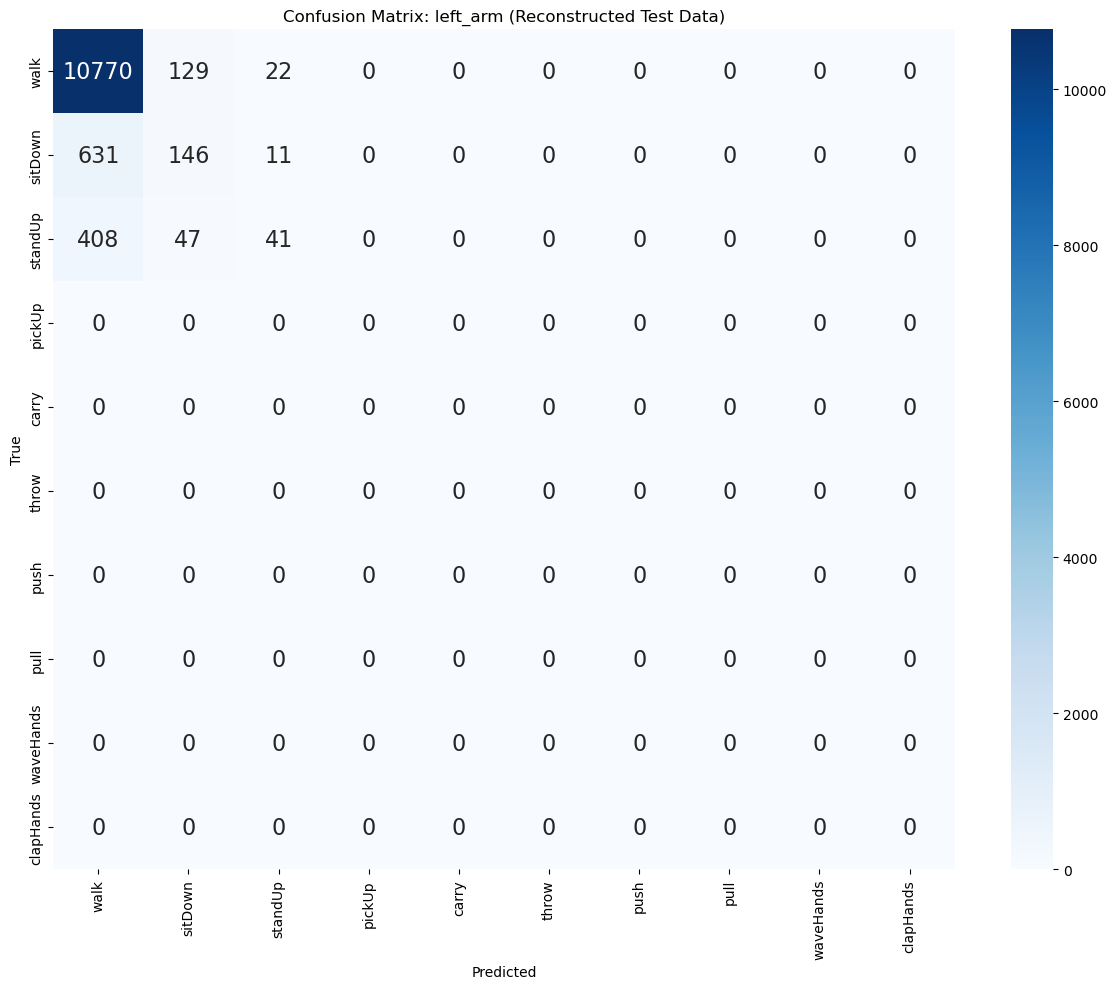


Metrics for left_arm:
Overall Accuracy: 0.8977
Balanced Accuracy: 0.4180
Weighted Accuracy (by support): 0.8977

Evaluating classifier on 20% reconstructed data for right_leg
Reconstructed test files for right_leg: ['joints_s01_e01_right_leg_reconstructed.txt', 'joints_s09_e02_right_leg_reconstructed.txt', 'joints_s08_e02_right_leg_reconstructed.txt', 'joints_s01_e02_right_leg_reconstructed.txt', 'joints_s05_e01_right_leg_reconstructed.txt', 'joints_s03_e02_right_leg_reconstructed.txt', 'joints_s06_e02_right_leg_reconstructed.txt', 'joints_s02_e02_right_leg_reconstructed.txt', 'joints_s10_e01_right_leg_reconstructed.txt', 'joints_s09_e01_right_leg_reconstructed.txt', 'joints_s07_e02_right_leg_reconstructed.txt', 'joints_s02_e01_right_leg_reconstructed.txt', 'joints_s05_e02_right_leg_reconstructed.txt', 'joints_s10_e02_right_leg_reconstructed.txt', 'joints_s03_e01_right_leg_reconstructed.txt', 'joints_s07_e01_right_leg_reconstructed.txt']
Invalid range for s01_e01: sitDown, 572, 686
In

C:\Users\hp\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Saved confusion matrix for right_leg to C:\Users\hp\Desktop\Transformer_Classification4paper\confusion_matrix_right_leg.png


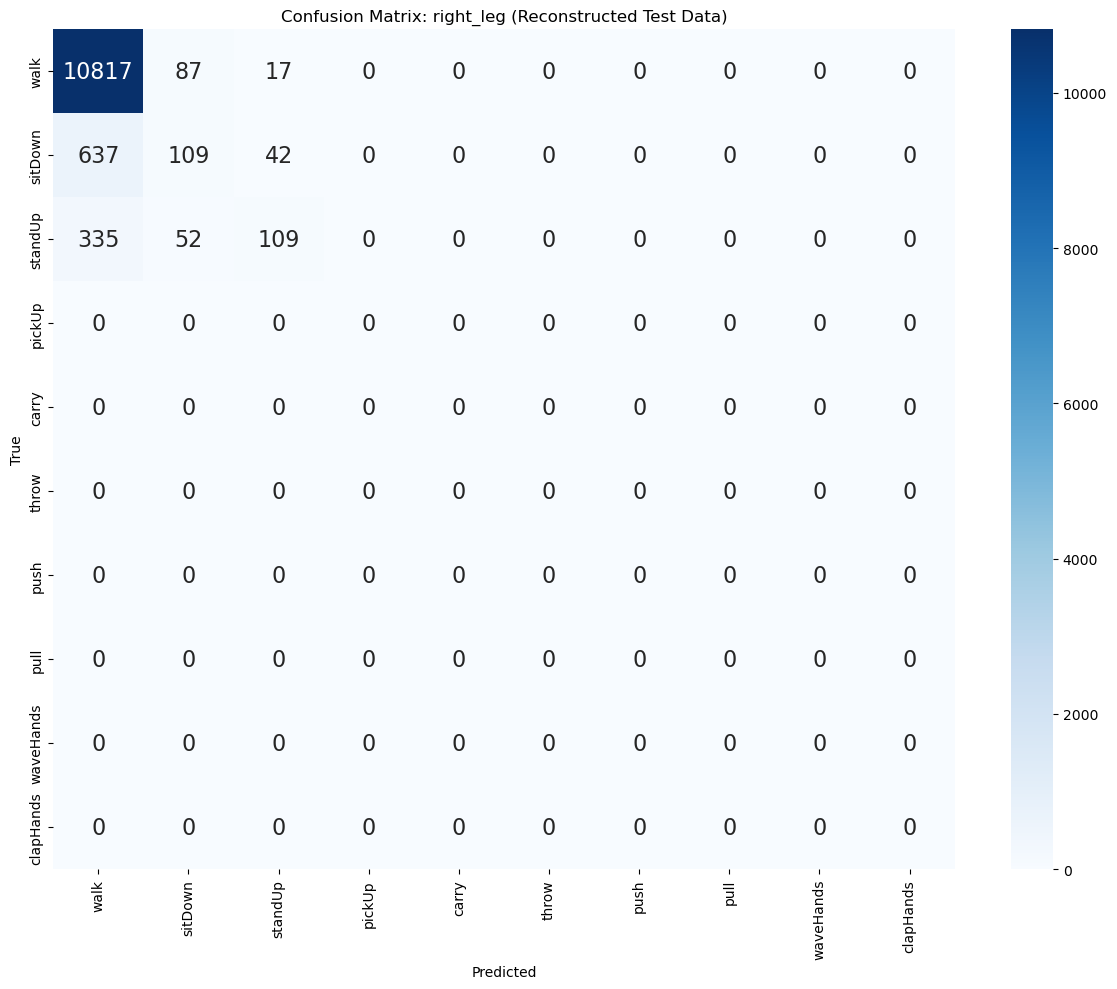


Metrics for right_leg:
Overall Accuracy: 0.9041
Balanced Accuracy: 0.4495
Weighted Accuracy (by support): 0.9041

Evaluating classifier on 20% reconstructed data for left_leg
Reconstructed test files for left_leg: ['joints_s01_e01_left_leg_reconstructed.txt', 'joints_s09_e02_left_leg_reconstructed.txt', 'joints_s08_e02_left_leg_reconstructed.txt', 'joints_s01_e02_left_leg_reconstructed.txt', 'joints_s05_e01_left_leg_reconstructed.txt', 'joints_s03_e02_left_leg_reconstructed.txt', 'joints_s06_e02_left_leg_reconstructed.txt', 'joints_s02_e02_left_leg_reconstructed.txt', 'joints_s10_e01_left_leg_reconstructed.txt', 'joints_s09_e01_left_leg_reconstructed.txt', 'joints_s07_e02_left_leg_reconstructed.txt', 'joints_s02_e01_left_leg_reconstructed.txt', 'joints_s05_e02_left_leg_reconstructed.txt', 'joints_s10_e02_left_leg_reconstructed.txt', 'joints_s03_e01_left_leg_reconstructed.txt', 'joints_s07_e01_left_leg_reconstructed.txt']
Invalid range for s01_e01: sitDown, 572, 686
Invalid range for s

C:\Users\hp\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Saved confusion matrix for left_leg to C:\Users\hp\Desktop\Transformer_Classification4paper\confusion_matrix_left_leg.png


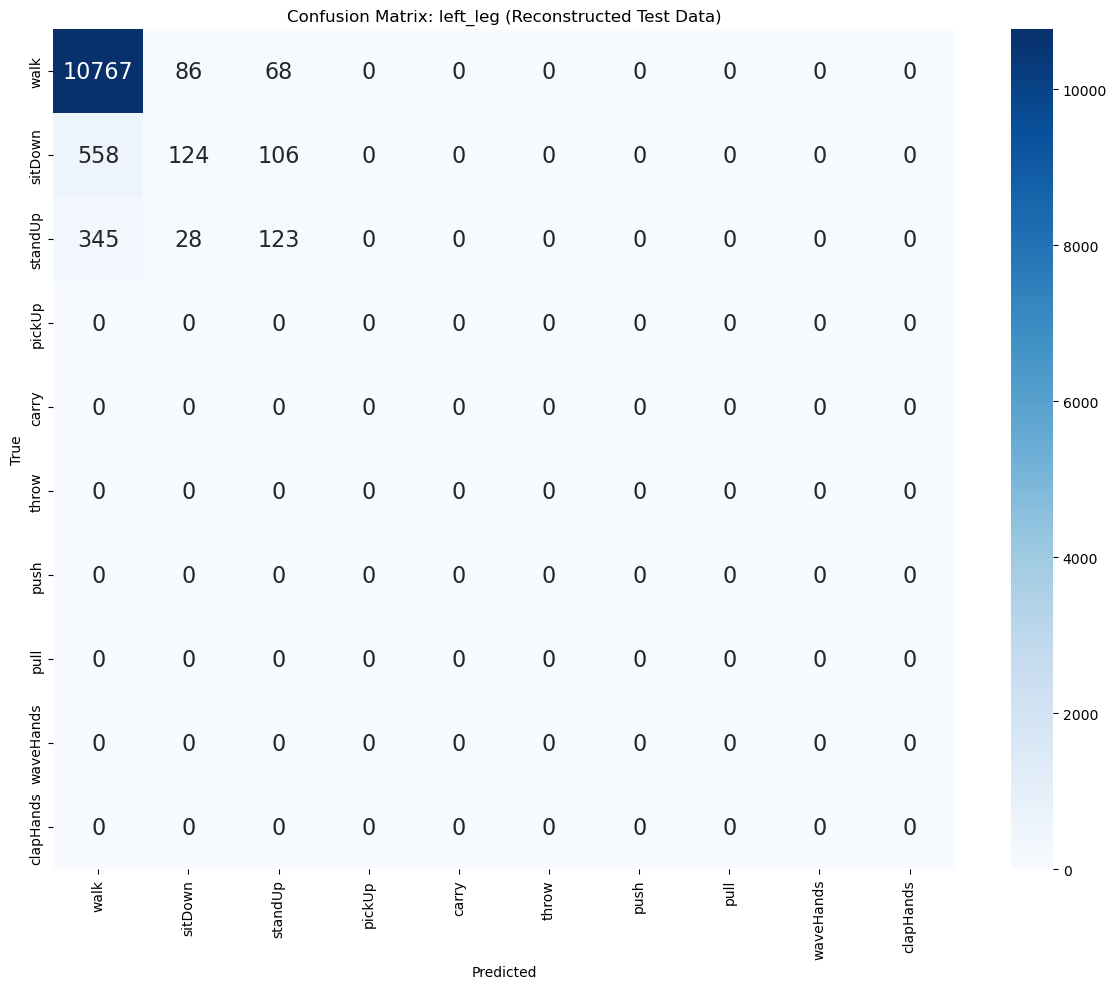


Metrics for left_leg:
Overall Accuracy: 0.9024
Balanced Accuracy: 0.4637
Weighted Accuracy (by support): 0.9024

Evaluating classifier on 20% reconstructed data for right_arm_leg
Reconstructed test files for right_arm_leg: ['joints_s01_e01_right_arm_leg_reconstructed.txt', 'joints_s09_e02_right_arm_leg_reconstructed.txt', 'joints_s08_e02_right_arm_leg_reconstructed.txt', 'joints_s01_e02_right_arm_leg_reconstructed.txt', 'joints_s05_e01_right_arm_leg_reconstructed.txt', 'joints_s03_e02_right_arm_leg_reconstructed.txt', 'joints_s06_e02_right_arm_leg_reconstructed.txt', 'joints_s02_e02_right_arm_leg_reconstructed.txt', 'joints_s10_e01_right_arm_leg_reconstructed.txt', 'joints_s09_e01_right_arm_leg_reconstructed.txt', 'joints_s07_e02_right_arm_leg_reconstructed.txt', 'joints_s02_e01_right_arm_leg_reconstructed.txt', 'joints_s05_e02_right_arm_leg_reconstructed.txt', 'joints_s10_e02_right_arm_leg_reconstructed.txt', 'joints_s03_e01_right_arm_leg_reconstructed.txt', 'joints_s07_e01_right_arm

C:\Users\hp\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Saved confusion matrix for right_arm_leg to C:\Users\hp\Desktop\Transformer_Classification4paper\confusion_matrix_right_arm_leg.png


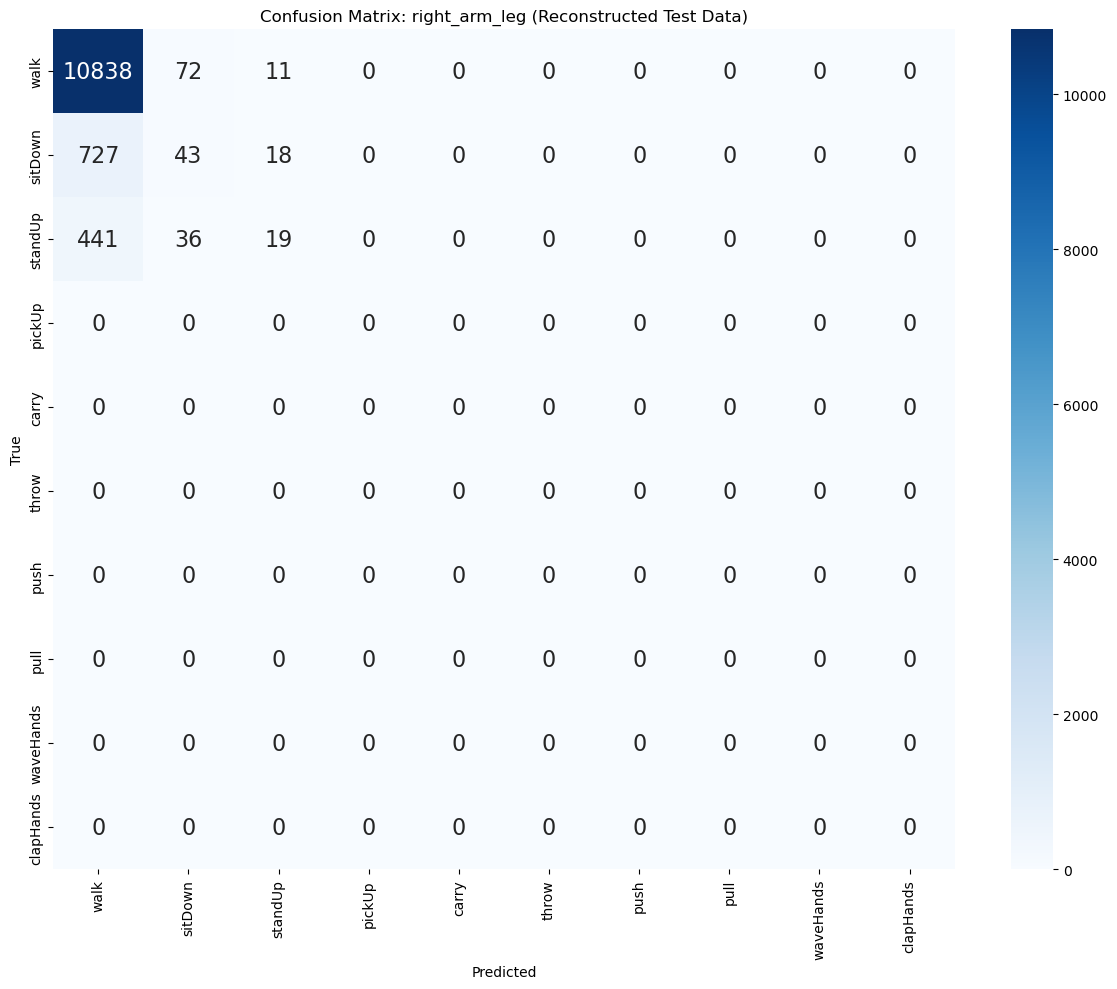


Metrics for right_arm_leg:
Overall Accuracy: 0.8931
Balanced Accuracy: 0.3618
Weighted Accuracy (by support): 0.8931

Evaluating classifier on 20% reconstructed data for left_arm_leg
Reconstructed test files for left_arm_leg: ['joints_s01_e01_left_arm_leg_reconstructed.txt', 'joints_s09_e02_left_arm_leg_reconstructed.txt', 'joints_s08_e02_left_arm_leg_reconstructed.txt', 'joints_s01_e02_left_arm_leg_reconstructed.txt', 'joints_s05_e01_left_arm_leg_reconstructed.txt', 'joints_s03_e02_left_arm_leg_reconstructed.txt', 'joints_s06_e02_left_arm_leg_reconstructed.txt', 'joints_s02_e02_left_arm_leg_reconstructed.txt', 'joints_s10_e01_left_arm_leg_reconstructed.txt', 'joints_s09_e01_left_arm_leg_reconstructed.txt', 'joints_s07_e02_left_arm_leg_reconstructed.txt', 'joints_s02_e01_left_arm_leg_reconstructed.txt', 'joints_s05_e02_left_arm_leg_reconstructed.txt', 'joints_s10_e02_left_arm_leg_reconstructed.txt', 'joints_s03_e01_left_arm_leg_reconstructed.txt', 'joints_s07_e01_left_arm_leg_reconstr

C:\Users\hp\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Saved confusion matrix for left_arm_leg to C:\Users\hp\Desktop\Transformer_Classification4paper\confusion_matrix_left_arm_leg.png


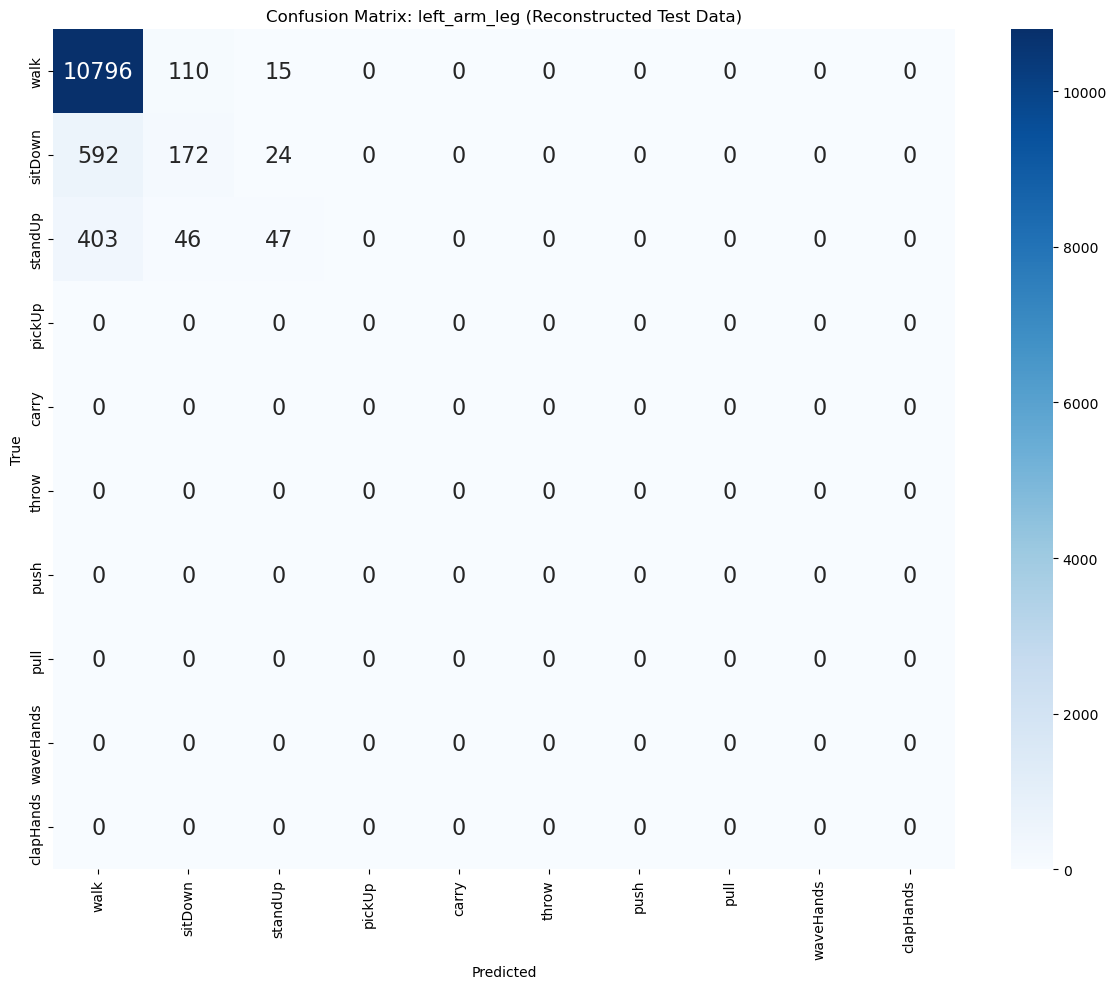


Metrics for left_arm_leg:
Overall Accuracy: 0.9025
Balanced Accuracy: 0.4339
Weighted Accuracy (by support): 0.9025

Evaluating classifier on 20% reconstructed data for both_arms
Reconstructed test files for both_arms: ['joints_s01_e01_both_arms_reconstructed.txt', 'joints_s09_e02_both_arms_reconstructed.txt', 'joints_s08_e02_both_arms_reconstructed.txt', 'joints_s01_e02_both_arms_reconstructed.txt', 'joints_s05_e01_both_arms_reconstructed.txt', 'joints_s03_e02_both_arms_reconstructed.txt', 'joints_s06_e02_both_arms_reconstructed.txt', 'joints_s02_e02_both_arms_reconstructed.txt', 'joints_s10_e01_both_arms_reconstructed.txt', 'joints_s09_e01_both_arms_reconstructed.txt', 'joints_s07_e02_both_arms_reconstructed.txt', 'joints_s02_e01_both_arms_reconstructed.txt', 'joints_s05_e02_both_arms_reconstructed.txt', 'joints_s10_e02_both_arms_reconstructed.txt', 'joints_s03_e01_both_arms_reconstructed.txt', 'joints_s07_e01_both_arms_reconstructed.txt']
Invalid range for s01_e01: sitDown, 572, 68

C:\Users\hp\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Saved confusion matrix for both_arms to C:\Users\hp\Desktop\Transformer_Classification4paper\confusion_matrix_both_arms.png


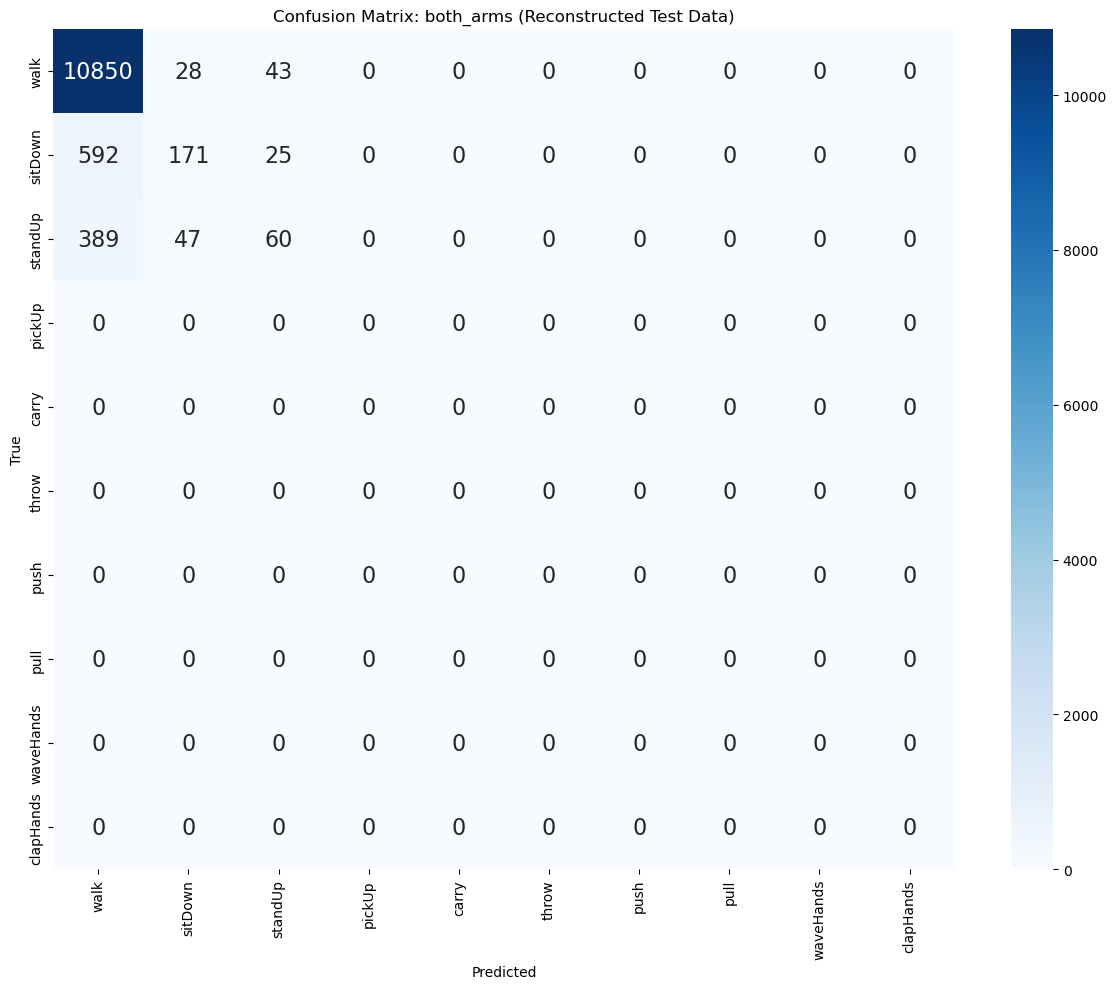


Metrics for both_arms:
Overall Accuracy: 0.9079
Balanced Accuracy: 0.4438
Weighted Accuracy (by support): 0.9079

Evaluating classifier on 20% reconstructed data for both_legs
Reconstructed test files for both_legs: ['joints_s01_e01_both_legs_reconstructed.txt', 'joints_s09_e02_both_legs_reconstructed.txt', 'joints_s08_e02_both_legs_reconstructed.txt', 'joints_s01_e02_both_legs_reconstructed.txt', 'joints_s05_e01_both_legs_reconstructed.txt', 'joints_s03_e02_both_legs_reconstructed.txt', 'joints_s06_e02_both_legs_reconstructed.txt', 'joints_s02_e02_both_legs_reconstructed.txt', 'joints_s10_e01_both_legs_reconstructed.txt', 'joints_s09_e01_both_legs_reconstructed.txt', 'joints_s07_e02_both_legs_reconstructed.txt', 'joints_s02_e01_both_legs_reconstructed.txt', 'joints_s05_e02_both_legs_reconstructed.txt', 'joints_s10_e02_both_legs_reconstructed.txt', 'joints_s03_e01_both_legs_reconstructed.txt', 'joints_s07_e01_both_legs_reconstructed.txt']
Invalid range for s01_e01: sitDown, 572, 686
I

C:\Users\hp\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Saved confusion matrix for both_legs to C:\Users\hp\Desktop\Transformer_Classification4paper\confusion_matrix_both_legs.png


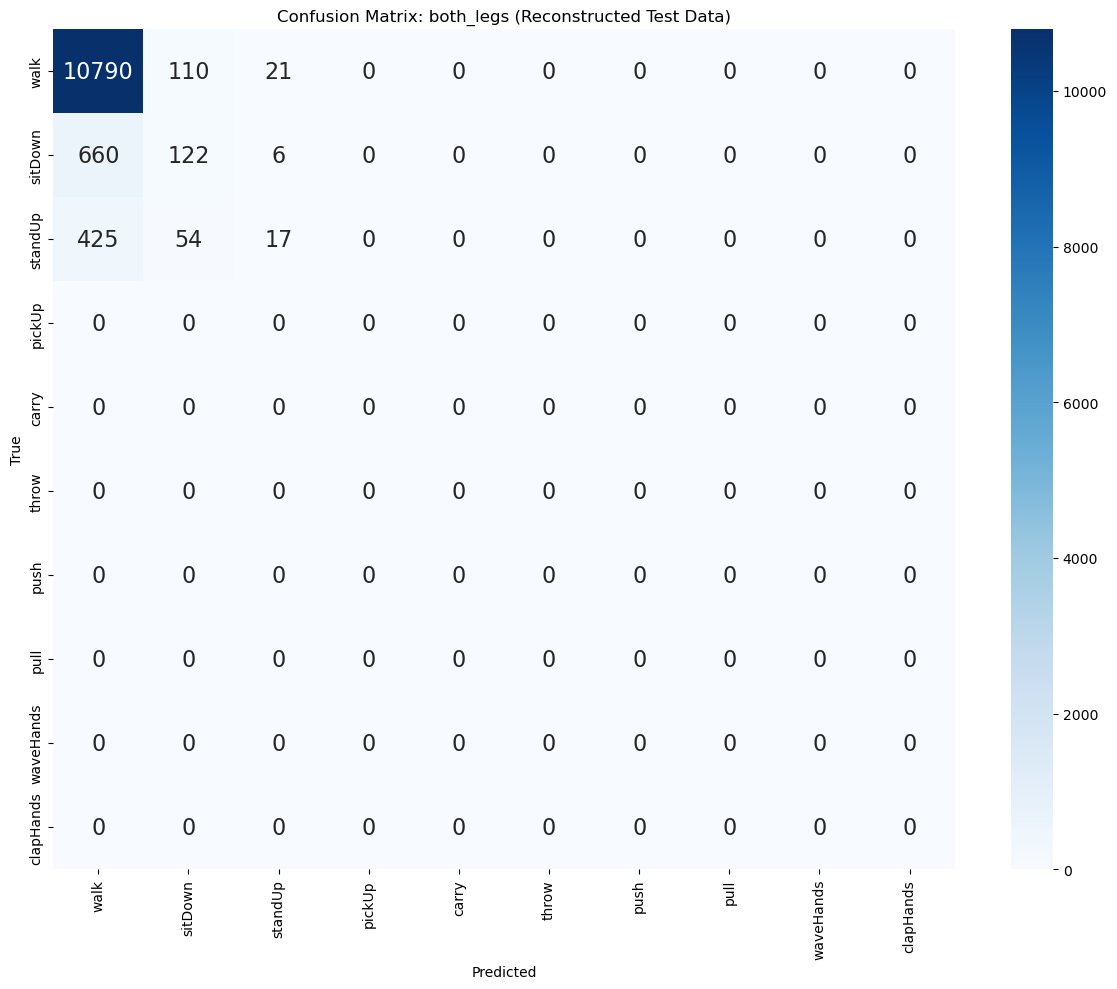


Metrics for both_legs:
Overall Accuracy: 0.8955
Balanced Accuracy: 0.3924
Weighted Accuracy (by support): 0.8955

Merged Evaluation Results for All Cases on 20% Reconstructed Data:
         Case    Action  Class Accuracy  F1 Score
    both_arms     carry          0.0000    0.0000
    both_arms clapHands          0.0000    0.0000
    both_arms    pickUp          0.0000    0.0000
    both_arms      pull          0.0000    0.0000
    both_arms      push          0.0000    0.0000
    both_arms   sitDown          0.2170    0.3308
    both_arms   standUp          0.1210    0.1923
    both_arms     throw          0.0000    0.0000
    both_arms      walk          0.9935    0.9538
    both_arms waveHands          0.0000    0.0000
    both_legs     carry          0.0000    0.0000
    both_legs clapHands          0.0000    0.0000
    both_legs    pickUp          0.0000    0.0000
    both_legs      pull          0.0000    0.0000
    both_legs      push          0.0000    0.0000
    both_legs   si

In [18]:
#Classification of activities Transformer

import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout, Add
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, f1_score, accuracy_score, balanced_accuracy_score
from sklearn.metrics import classification_report
import pandas as pd

# --------------- Action Labels ---------------
action_ranges = {
    "s01_e01": [("walk", 252, 390), ("sitDown", 572, 686), ("standUp", 704, 752),
                ("pickUp", 822, 954), ("carry", 1016, 1242), ("throw", 1434, 1488),
                ("push", 1686, 1748), ("pull", 1640, 1686), ("waveHands", 1834, 2064),
                ("clapHands", 2110, 2228)],
    "s01_e02": [("walk", 154, 192), ("sitDown", 530, 628), ("standUp", 640, 720),
                ("pickUp", 1202, 1356), ("carry", 1364, 1520), ("throw", 2246, 2294),
                ("push", 2752, 2792), ("pull", 2820, 2858), ("waveHands", 2984, 3204),
                ("clapHands", 3250, 3448)],
    "s02_e01": [("walk", 266, 368), ("sitDown", 672, 788), ("standUp", 818, 910),
                ("pickUp", 1262, 1386), ("carry", 1424, 1780), ("throw", 2040, 2086),
                ("push", 2340, 2376), ("pull", 2488, 2550), ("waveHands", 2668, 2830),
                ("clapHands", 3198, 3324)],
    "s02_e02": [("walk", 40, 208), ("sitDown", 468, 602), ("standUp", 620, 722),
                ("pickUp", 894, 1038), ("carry", 1340, 1480), ("throw", 1966, 2014),
                ("push", 2194, 2230), ("pull", 2314, 2358), ("waveHands", 2408, 2630),
                ("clapHands", 2690, 2810)],
    "s03_e01": [("walk", 372, 528), ("sitDown", 734, 862), ("standUp", 902, 1000),
                ("pickUp", 1118, 1284), ("carry", 1934, 2168), ("throw", 3226, 3282),
                ("push", 3556, 3622), ("pull", 3660, 3730), ("waveHands", 3806, 3960),
                ("clapHands", 4076, 4184)],
    "s03_e02": [("walk", 122, 254), ("sitDown", 452, 592), ("standUp", 644, 724),
                ("pickUp", 848, 1018), ("carry", 1078, 1192), ("throw", 1638, 1690),
                ("push", 1866, 1896), ("pull", 1928, 2008), ("waveHands", 2054, 2208),
                ("clapHands", 2324, 2460)],
    "s04_e01": [("walk", 348, 496), ("sitDown", 788, 864), ("standUp", 954, 1056),
                ("pickUp", 1190, 1326), ("carry", 1580, 1882), ("throw", 2306, 2350),
                ("push", 2532, 2572), ("pull", 2644, 2686), ("waveHands", 2790, 2968),
                ("clapHands", 3064, 3146)],
    "s04_e02": [("walk", 420, 546), ("sitDown", 1046, 1144), ("standUp", 1352, 1414),
                ("pickUp", 1682, 1820), ("carry", 1868, 2122), ("throw", 2564, 2608),
                ("push", 2760, 2792), ("pull", 2866, 2910), ("waveHands", 3070, 3260),
                ("clapHands", 3448, 3622)],
    "s05_e01": [("walk", 708, 888), ("sitDown", 1140, 1238), ("standUp", 1294, 1394),
                ("pickUp", 1482, 1676), ("carry", 1736, 2064), ("throw", 3104, 3176),
                ("push", 3596, 3632), ("pull", 3706, 3770), ("waveHands", 3946, 4352),
                ("clapHands", 4522, 4734)],
    "s05_e02": [("walk", 212, 376), ("sitDown", 634, 756), ("standUp", 788, 862),
                ("pickUp", 974, 1180), ("carry", 1266, 1540), ("throw", 1752, 1828),
                ("push", 2172, 2230), ("pull", 2104, 2156), ("waveHands", 2504, 2784),
                ("clapHands", 2798, 2900)],
    "s06_e01": [("walk", 1230, 1366), ("sitDown", 1564, 1644), ("standUp", 1678, 1758),
                ("pickUp", 1862, 1948), ("carry", 1966, 2098), ("throw", 2392, 2414),
                ("push", 2672, 2698), ("pull", 2790, 2824), ("waveHands", 3046, 3216),
                ("clapHands", 3290, 3444)],
    "s06_e02": [("walk", 294, 426), ("sitDown", 710, 818), ("standUp", 856, 956),
                ("pickUp", 1088, 1174), ("carry", 2031, 2202), ("throw", 2518, 2562),
                ("push", 2702, 2726), ("pull", 2770, 2808), ("waveHands", 2952, 3060),
                ("clapHands", 3096, 3188)],
    "s07_e01": [("walk", 130, 252), ("sitDown", 1038, 1186), ("standUp", 1256, 1372),
                ("pickUp", 1450, 1602), ("carry", 1602, 1758), ("throw", 2534, 2614),
                ("push", 3290, 3350), ("pull", 3350, 3522), ("waveHands", 3666, 3902),
                ("clapHands", 3990, 4128)],
    "s07_e02": [("walk", 552, 638), ("sitDown", 880, 1014), ("standUp", 1014, 1146),
                ("pickUp", 1228, 1352), ("carry", 1352, 1518), ("throw", 1990, 2058),
                ("push", 2434, 2496), ("pull", 2496, 2618), ("waveHands", 2672, 2982),
                ("clapHands", 3042, 3152)],
    "s08_e01": [("walk", 446, 534), ("sitDown", 714, 812), ("standUp", 836, 900),
                ("pickUp", 1026, 1144), ("carry", 1228, 1588), ("throw", 1880, 1916),
                ("push", 2236, 2268), ("pull", 2334, 2398), ("waveHands", 2598, 2772),
                ("clapHands", 2794, 2892)],
    "s08_e02": [("walk", 138, 246), ("sitDown", 610, 716), ("standUp", 770, 878),
                ("pickUp", 1126, 1200), ("carry", 1364, 1650), ("throw", 1826, 1878),
                ("push", 2030, 2078), ("pull", 2126, 2204), ("waveHands", 2280, 2506),
                ("clapHands", 2574, 2650)],
    "s09_e01": [("walk", 404, 544), ("sitDown", 1080, 1196), ("standUp", 1212, 1290),
                ("pickUp", 1422, 1538), ("carry", 1668, 1970), ("throw", 2688, 2728),
                ("push", 3266, 3316), ("pull", 3316, 3390), ("waveHands", 3576, 3762),
                ("clapHands", 3992, 4118)],
    "s09_e02": [("walk", 482, 610), ("sitDown", 1026, 1158), ("standUp", 1206, 1310),
                ("pickUp", 1546, 1678), ("carry", 1714, 2120), ("throw", 2468, 2522),
                ("push", 2696, 2760), ("pull", 2770, 2838), ("waveHands", 4708, 4872),
                ("clapHands", 4904, 4964)],
    "s10_e01": [("walk", 100, 272), ("sitDown", 562, 730), ("standUp", 730, 862),
                ("pickUp", 924, 1150), ("carry", 1394, 1846), ("throw", 3304, 3388),
                ("push", 3468, 3524), ("pull", 3524, 3608), ("waveHands", 3962, 4222),
                ("clapHands", 4268, 4336)],
    "s10_e02": [("walk", 96, 220), ("sitDown", 500, 658), ("standUp", 664, 770),
                ("pickUp", 1022, 1232), ("carry", "NaN", "NaN"), ("throw", 1720, 1810),
                ("push", 1944, 1994), ("pull", 1982, 2062), ("waveHands", 2094, 2350),
                ("clapHands", 2454, 2598)]
}

# --------------- Data Utilities ---------------
def load_skeleton_file(file_path):
    data = []
    with open(file_path, 'r') as f:
        for line in f:
            line = line.strip()
            if line.startswith('#') or not line:
                continue
            try:
                parts = list(map(float, line.split()))
                if len(parts) == 61:
                    data.append(parts[1:])
                else:
                    print(f"Warning: Skipping line in {file_path} with incorrect number of values ({len(parts)} != 61)")
            except ValueError as e:
                print(f"Warning: Skipping invalid line in {file_path}: {line} ({str(e)})")
    if not data:
        print(f"Warning: No valid data in {file_path}")
    return np.array(data)

def load_all_skeletons_and_labels(real_dir, rec_dir=None, case=None, train=True):
    all_data = []
    all_labels = []
    action_mapping = {
        0: 'walk', 1: 'sitDown', 2: 'standUp', 3: 'pickUp', 4: 'carry',
        5: 'throw', 6: 'push', 7: 'pull', 8: 'waveHands', 9: 'clapHands'
    }
    
    # Load real data (80% for training, 20% for test file names)
    files = [f for f in os.listdir(real_dir) if f.endswith(".txt")]
    if len(files) != 20:
        print(f"Warning: Expected 20 files in {real_dir}, found {len(files)}")
    
    train_files, test_files = train_test_split(files, train_size=0.8, random_state=42)
    
    # For training, load 80% real data
    if train:
        selected_files = train_files
        print(f"Real training files: {selected_files}")
        for filename in selected_files:
            file_key = filename.replace('joints_', '').replace('.txt', '')
            full_path = os.path.join(real_dir, filename)
            sequence = load_skeleton_file(full_path)
            num_frames = len(sequence)
            
            labels = np.zeros(num_frames, dtype=int)
            if file_key in action_ranges:
                for action, start, end in action_ranges[file_key]:
                    if isinstance(start, str) or isinstance(end, str):
                        continue
                    start, end = int(start), int(end)
                    if start >= 0 and end <= num_frames and start < end:
                        action_id = [k for k, v in action_mapping.items() if v == action][0]
                        labels[start:end] = action_id
                    else:
                        print(f"Invalid range for {file_key}: {action}, {start}, {end}")
            else:
                print(f"No action ranges for {filename}, using default labels.")
            
            all_data.append(sequence)
            all_labels.append(labels)
    
    return all_data, all_labels, action_mapping, test_files

# --------------- Classifier Model ---------------
def build_classifier(T=30, num_features=60, num_classes=10):
    inp = Input(shape=(T, num_features))
    x = inp
    x_res = x
    x = Dense(60, activation='relu')(x)
    x = Add()([x, x_res])
    x = LSTM(225, return_sequences=True)(x)
    x = Dropout(0.3)(x)
    x = LSTM(256, return_sequences=False)(x)
    x = Dropout(0.3)(x)
    out = Dense(num_classes, activation='softmax')(x)
    return Model(inp, out, name="ActionClassifier")

# --------------- Training ---------------
def train_classifier(sequences, labels, action_mapping, T=30, epochs=100, batch_size=32):
    # Normalize
    all_frames = np.concatenate(sequences)
    min_vals = all_frames.min(axis=0)
    max_vals = all_frames.max(axis=0)
    ranges = max_vals - min_vals + 1e-6
    
    # Add noise for augmentation
    def add_noise(sequence, noise_level=0.01):
        noise = np.random.normal(0, noise_level, sequence.shape)
        return sequence + noise
    
    # Apply normalization and noise
    sequences = [add_noise((seq - min_vals) / ranges) for seq in sequences]

    # Prepare sequences of T frames
    X, y = [], []
    for seq, seq_labels in zip(sequences, labels):
        for i in range(0, len(seq) - T + 1):
            X.append(seq[i:i+T])
            y.append(seq_labels[i+T-1])
    X = np.array(X)
    y = np.array(y)

    # Use 10% validation data
    x_train, x_val, y_train, y_val = train_test_split(X, y, test_size=0.1, random_state=42, stratify=y)

    classifier = build_classifier(T=T, num_features=60, num_classes=len(np.unique(y)))
    classifier.compile(optimizer=Adam(1e-4), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

    history = classifier.fit(x_train, y_train, validation_data=(x_val, y_val), epochs=epochs, batch_size=batch_size, verbose=1)

    # Confusion Matrix for validation set
    y_pred = classifier.predict(x_val)
    y_pred_classes = np.argmax(y_pred, axis=1)
    cm = confusion_matrix(y_val, y_pred_classes)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', annot_kws={"size": 16}, xticklabels=list(action_mapping.values()), yticklabels=list(action_mapping.values()))
    plt.title('Confusion Matrix (Validation Set)')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

    # Print detailed metrics
    print("\nValidation Set Metrics:")
    print(classification_report(y_val, y_pred_classes, target_names=list(action_mapping.values()), labels=list(range(10))))

    return classifier, min_vals, ranges, history

# --------------- Prediction for Reconstructed Cases ---------------
def evaluate_reconstructed_cases(classifier, rec_dir, min_vals, ranges, action_mapping, case, T=30):
    true_labels = []
    pred_labels = []
    
    # Load reconstructed test data
    case_path = os.path.join(rec_dir, case)
    if not os.path.exists(case_path):
        print(f"Error: Directory {case_path} does not exist, skipping.")
        return None
    
    # Get all files in the case directory
    all_files = [f for f in os.listdir(case_path) if f.endswith(f"{case}_reconstructed.txt")]
    if not all_files:
        print(f"Error: No reconstructed files found in {case_path}, skipping.")
        return None
    
    # Select 20% of the files
    test_files = train_test_split(all_files, train_size=0.2, random_state=42)[1]
    print(f"Reconstructed test files for {case}: {test_files}")
    
    for filename in test_files:
        # Extract the base file key (e.g., s01_e01) by removing the case-specific suffix
        file_key = filename.replace('joints_', '').replace(f'_{case}_reconstructed.txt', '')
        full_path = os.path.join(case_path, filename)
        
        sequence = load_skeleton_file(full_path)
        num_frames = len(sequence)
        if num_frames < T:
            print(f"Warning: Sequence {filename} has {num_frames} frames, less than T={T}, skipping.")
            continue
        
        # Generate labels
        labels = np.zeros(num_frames, dtype=int)
        if file_key in action_ranges:
            for action, start, end in action_ranges[file_key]:
                if isinstance(start, str) or isinstance(end, str):
                    continue
                start, end = int(start), int(end)
                if start >= 0 and end <= num_frames and start < end:
                    action_id = [k for k, v in action_mapping.items() if v == action][0]
                    labels[start:end] = action_id
                else:
                    print(f"Invalid range for {file_key}: {action}, {start}, {end}")
        else:
            print(f"No action ranges for {filename}, using default labels.")
        
        # Normalize sequence
        sequence = (sequence - min_vals) / ranges
        
        # Process sequence in windows of T frames
        for i in range(0, len(sequence) - T + 1):
            input_seq = sequence[i:i+T]
            input_seq = np.expand_dims(input_seq, axis=0)
            pred = classifier.predict(input_seq, verbose=0)
            pred_class = np.argmax(pred, axis=1)[0]
            true_label = labels[i+T-1]
            true_labels.append(true_label)
            pred_labels.append(pred_class)
    
    if not true_labels:
        print(f"No valid frames for case {case}, skipping.")
        return None
    
    # Compute metrics
    f1 = f1_score(true_labels, pred_labels, average=None, labels=list(range(10)))
    cm = confusion_matrix(true_labels, pred_labels, labels=list(range(10)))
    class_counts = np.sum(cm, axis=1)
    per_class_acc = np.zeros(10)
    for i in range(10):
        if class_counts[i] > 0:
            per_class_acc[i] = cm[i, i] / class_counts[i]
        else:
            per_class_acc[i] = 0.0
    class_weights = class_counts / (np.sum(class_counts) + 1e-6)
    weighted_acc = np.sum(per_class_acc * class_weights)
    
    # Plot and show confusion matrix
    plt.figure(figsize=(12, 10))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', annot_kws={"size": 16}, xticklabels=list(action_mapping.values()), yticklabels=list(action_mapping.values()))
    plt.title(f'Confusion Matrix: {case} (Reconstructed Test Data)')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.tight_layout()
    
    # Save confusion matrix
    output_dir = os.path.join(os.path.expanduser("~"), "Desktop", "Transformer_Classification4paper")
    os.makedirs(output_dir, exist_ok=True)
    cm_path = os.path.join(output_dir, f'confusion_matrix_{case}.png')
    try:
        plt.savefig(cm_path)
        print(f"Saved confusion matrix for {case} to {cm_path}")
    except Exception as e:
        print(f"Error: Could not save confusion matrix to {cm_path}: {e}")
    
    # Display the confusion matrix
    plt.show()
    
    # Print overall metrics
    overall_acc = accuracy_score(true_labels, pred_labels)
    balanced_acc = balanced_accuracy_score(true_labels, pred_labels)
    print(f"\nMetrics for {case}:")
    print(f"Overall Accuracy: {overall_acc:.4f}")
    print(f"Balanced Accuracy: {balanced_acc:.4f}")
    print(f"Weighted Accuracy (by support): {weighted_acc:.4f}")
    
    # Collect results for table
    results = []
    for i, action in action_mapping.items():
        results.append({
            'Case': case,
            'Action': action,
            'Class Accuracy': round(per_class_acc[i], 4),
            'F1 Score': round(f1[i], 4) if i < len(f1) else 0.0
        })
    
    return results

# --------------- Run Script ---------------
if __name__ == "__main__":
    real_dir = "D:/Thesis/DATA/joints1/joints"
    #rec_dir = os.path.join(os.path.expanduser("~"), "Desktop", "CRNN-Test")
    rec_dir = "E:/PAPER Codes and research/transformer"
    action_mapping = {
        0: 'walk', 1: 'sitDown', 2: 'standUp', 3: 'pickUp', 4: 'carry',
        5: 'throw', 6: 'push', 7: 'pull', 8: 'waveHands', 9: 'clapHands'
    }
    cases = [
        "right_arm", "left_arm", "right_leg", "left_leg",
        "right_arm_leg", "left_arm_leg", "both_arms", "both_legs"
    ]

    # Load training data (80% real data) and get test file names
    train_data, train_labels, action_mapping, test_files = load_all_skeletons_and_labels(real_dir, train=True)
    
    # Train classifier on 80% real data
    print("\nTraining classifier with 80% real data")
    classifier, min_vals, ranges, history = train_classifier(train_data, train_labels, action_mapping)

    # Plot training history
    plt.figure(figsize=(10, 6))
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Model Accuracy (Real Data Training)')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.show()

    all_results = []

    # Evaluate on 20% reconstructed data for each case
    for case in cases:
        print(f"\nEvaluating classifier on 20% reconstructed data for {case}")
        case_results = evaluate_reconstructed_cases(classifier, rec_dir, min_vals, ranges, action_mapping, case)
        if case_results is not None:
            all_results.extend(case_results)

    # Create and print merged results table
    results_table = pd.DataFrame(all_results)
    results_table = results_table.sort_values(by=['Case', 'Action']).reset_index(drop=True)
    print("\nMerged Evaluation Results for All Cases on 20% Reconstructed Data:")
    print(results_table.to_string(index=False))
    
    # Save results table to CSV with error handling
    output_dir = os.path.join(os.path.expanduser("~"), "Desktop", "Transformer_Classification4paper")
    os.makedirs(output_dir, exist_ok=True)
    results_path = os.path.join(output_dir, 'results_table.csv')
    try:
        results_table.to_csv(results_path, index=False)
        print(f"Saved results table to {results_path}")
    except PermissionError as e:
        print(f"Error: Could not save results table to {results_path} due to permission issues: {e}")
        print("Please ensure the file is not open in another program and you have write permissions for the directory.")
        print("Alternatively, try running the script as an administrator or choose a different output directory.")
    except Exception as e:
        print(f"Error: Failed to save results table to {results_path}: {e}")

In [ ]:
#CRNN based GAN
#CRNN code with reconstructed files in output

import numpy as np
import tensorflow as tf
import os
import matplotlib.pyplot as plt
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout, Conv1D, LSTM, TimeDistributed, LeakyReLU, Reshape, Flatten, Concatenate, Bidirectional
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import pandas as pd
from scipy.interpolate import interp1d

# -------------------- Parameters --------------------
Tm = 30                # model window size
NUM_JOINTS = 20
JOINT_DIM = 3
FEATURES_PER_FRAME = 1 + NUM_JOINTS * JOINT_DIM  # 61 (frame_number + 60 coords)
LAMBDA = 50
BATCH_SIZE = 10
STRIDE = 1             # sliding window stride (1 -> best quality)
EPOCHS = 150
RESULTS_DIR = "E:/PAPER Codes and research/CRNN3"  # CHANGE to your path
os.makedirs(RESULTS_DIR, exist_ok=True)

BONES = [
    (0, 1), (1, 2), (2, 3), (2, 4), (4, 5), (5, 6), (6, 7),
    (2, 8), (8, 9), (9, 10), (10, 11),
    (0, 12), (12, 13), (13, 14), (14, 15),
    (0, 16), (16, 17), (17, 18), (18, 19)
]

# -------------------- Helpers --------------------
def interpolate_to_fixed_length(data, target_length):
    # data: (orig_len, J, D) -> (target_length, J, D)
    if data.shape[0] == target_length:
        return data.astype(np.float32)
    x_old = np.linspace(0.0, 1.0, data.shape[0])
    x_new = np.linspace(0.0, 1.0, target_length)
    f = interp1d(x_old, data, axis=0, kind='linear', fill_value='extrapolate')
    return f(x_new).astype(np.float32)

def load_with_timestamps(file_path):
    """
    Format A: first column = frame number, remaining 60 columns = coords
    returns: timestamps (orig_len,), coords (orig_len, J, D), orig_len
    """
    raw = np.loadtxt(file_path, dtype=np.float32)
    if raw.ndim == 1:
        raw = raw.reshape(1, -1)
    timestamps = raw[:, 0].astype(np.float32)
    coords = raw[:, 1:].astype(np.float32)
    orig_len = coords.shape[0]
    coords = coords.reshape((orig_len, NUM_JOINTS, JOINT_DIM))
    return timestamps, coords, orig_len

def normalize_sequences(seqs):
    # seqs shape: (B, T, J, D)
    b, t, j, d = seqs.shape
    flat = seqs.reshape(-1, d)
    scaler = MinMaxScaler(feature_range=(-1, 1))
    norm = scaler.fit_transform(flat).reshape(b, t, j, d)
    return norm.astype(np.float32), scaler

def denormalize_sequences(seqs, scaler):
    # seqs shape: (B, T, J, D)
    b, t, j, d = seqs.shape
    flat = scaler.inverse_transform(seqs.reshape(-1, d))
    return flat.reshape(b, t, j, d).astype(np.float32)

# -------------------- Model Building --------------------
def build_crnn_generator(Tm, NUM_JOINTS, JOINT_DIM):
    inputs = Input(shape=(Tm, NUM_JOINTS * JOINT_DIM), dtype=tf.float32)
    x = Reshape((Tm, NUM_JOINTS, JOINT_DIM))(inputs)
    x = TimeDistributed(Flatten())(x)
    x = Conv1D(64, 3, padding='same')(x)
    x = LeakyReLU(0.2)(x)
    x = Conv1D(64, 3, padding='same')(x)
    x = LeakyReLU(0.2)(x)
    x = Bidirectional(LSTM(256, return_sequences=True))(x)
    x = Dropout(0.25)(x)
    x = TimeDistributed(Dense(NUM_JOINTS * JOINT_DIM))(x)
    outputs = Reshape((Tm, NUM_JOINTS, JOINT_DIM))(x)
    return Model(inputs, outputs, name="CRNNGenerator")

def build_discriminator():
    real_in = Input(shape=(Tm, NUM_JOINTS, JOINT_DIM), dtype=tf.float32)
    gen_in = Input(shape=(Tm, NUM_JOINTS, JOINT_DIM), dtype=tf.float32)
    x_real = TimeDistributed(Flatten())(real_in)
    x_gen = TimeDistributed(Flatten())(gen_in)
    x = Concatenate()([x_real, x_gen])
    x = LSTM(256, return_sequences=False)(x)
    x = Dropout(0.25)(x)
    x = Dense(256, activation='relu')(x)
    out = Dense(1, activation='sigmoid')(x)
    return Model([real_in, gen_in], out, name="Discriminator")

def build_gan(generator, discriminator):
    discriminator.trainable = False
    occluded_input = Input(shape=(Tm, NUM_JOINTS, JOINT_DIM), dtype=tf.float32)
    real_input = Input(shape=(Tm, NUM_JOINTS, JOINT_DIM), dtype=tf.float32)
    flatten_input = Reshape((Tm, NUM_JOINTS * JOINT_DIM))(occluded_input)
    gen_out = generator(flatten_input)
    validity = discriminator([real_input, gen_out])
    model = Model([occluded_input, real_input], [validity, gen_out], name="GAN")
    discriminator.trainable = True
    return model

# -------------------- Losses --------------------
def bone_length_loss(real, gen):
    loss = tf.constant(0.0, dtype=tf.float32)
    for a, b in BONES:
        real_len = tf.norm(real[:, :, a] - real[:, :, b], axis=-1)
        gen_len = tf.norm(gen[:, :, a] - gen[:, :, b], axis=-1)
        loss += tf.reduce_mean(tf.square(real_len - gen_len))
    return loss

def temporal_smoothness_loss(real, gen):
    return tf.reduce_mean(tf.square((real[:,1:] - real[:,:-1]) - (gen[:,1:] - gen[:,:-1])))

def pix2pix_loss(real, gen, validity, l1_lambda=LAMBDA):
    bce = tf.keras.losses.BinaryCrossentropy()
    mae = tf.keras.losses.MeanAbsoluteError()
    adv_loss = bce(tf.ones_like(validity), validity)
    l1_loss = mae(real, gen)
    bone_loss = bone_length_loss(real, gen)
    temp_loss = temporal_smoothness_loss(real, gen)
    return adv_loss + l1_lambda * (l1_loss + bone_loss + temp_loss)

# -------------------- Training Function (unchanged behavior) --------------------
def train_gan(real_seqs, occluded_seqs, generator, discriminator, gan, scaler, epochs=EPOCHS, batch_size=BATCH_SIZE):
    valid = np.ones((batch_size, 1), dtype=np.float32)
    fake = np.zeros((batch_size, 1), dtype=np.float32)
    bce = tf.keras.losses.BinaryCrossentropy()
    optimizer_g = tf.keras.optimizers.Adam(0.001)
    optimizer_d = tf.keras.optimizers.Adam(0.001)

    norm_real = scaler.transform(real_seqs.reshape(-1, JOINT_DIM)).reshape(real_seqs.shape).astype(np.float32)
    norm_occluded = scaler.transform(occluded_seqs.reshape(-1, JOINT_DIM)).reshape(occluded_seqs.shape).astype(np.float32)

    for epoch in range(epochs):
        idx = np.random.randint(0, norm_real.shape[0], batch_size)
        real_batch = norm_real[idx]
        occluded_batch = norm_occluded[idx]

        gen_batch = generator.predict(occluded_batch.reshape((batch_size, Tm, NUM_JOINTS * JOINT_DIM)))

        with tf.GradientTape() as tape_d:
            d_real = discriminator([real_batch, real_batch])
            d_fake = discriminator([real_batch, gen_batch])
            d_loss = bce(valid, d_real) + bce(fake, d_fake)
        grads_d = tape_d.gradient(d_loss, discriminator.trainable_weights)
        optimizer_d.apply_gradients(zip(grads_d, discriminator.trainable_weights))

        with tf.GradientTape() as tape_g:
            validity, generated = gan([occluded_batch, real_batch], training=True)
            g_loss = pix2pix_loss(real_batch, generated, validity, LAMBDA)
        grads_g = tape_g.gradient(g_loss, generator.trainable_weights)
        optimizer_g.apply_gradients(zip(grads_g, generator.trainable_weights))

        if epoch % 10 == 0:
            print(f"Epoch {epoch} | D Loss: {d_loss.numpy():.4f} | G Loss: {g_loss.numpy():.4f}")

# -------------------- Evaluation helper --------------------
def split_and_evaluate(real_seqs, occluded_seqs, generator, scaler, case):
    X_train, X_temp, y_train, y_temp = train_test_split(occluded_seqs, real_seqs, test_size=0.2, random_state=42)
    X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

    def weighted_accuracy(y_true, y_pred):
        diff = np.abs(y_true - y_pred)
        norm = np.abs(y_true) + 1e-6
        acc = 1 - (diff / norm)
        acc = np.clip(acc, 0, 1)
        return np.mean(acc)

    def joint_wise_mse(y_true, y_pred):
        errors = np.mean((y_true - y_pred) ** 2, axis=(0, 1))
        return errors.reshape((NUM_JOINTS, JOINT_DIM))

    def evaluate(name, X, y):
        norm_X = scaler.transform(X.reshape(-1, JOINT_DIM)).reshape(X.shape).astype(np.float32)
        pred = generator.predict(norm_X.reshape((X.shape[0], Tm, NUM_JOINTS * JOINT_DIM)))
        pred = denormalize_sequences(pred, scaler)
        mse = np.mean((y - pred) ** 2)
        mae = np.mean(np.abs(y - pred))
        wacc = weighted_accuracy(y, pred)
        joint_errors = joint_wise_mse(y, pred)
        # visualize last frame of first sample (optional)
        # visualize_skeletons(y[0, -1], X[0, -1], pred[0, -1], f"{name} Sample (Last Frame)")
        print(f"Joint-wise MSE ({name}):\n", joint_errors)
        return {"Set": name, "MSE": mse, "MAE": mae, "WAcc": wacc}

    df = pd.DataFrame([
        evaluate("Train", X_train, y_train),
        evaluate("Val", X_val, y_val),
        evaluate("Test", X_test, y_test)
    ])
    
    csv_path = os.path.join(RESULTS_DIR, f"{case}_results.csv")
    df.to_csv(csv_path, index=False)
    print(f"Results for {case} saved to {csv_path}")
    return df

# --- Full-length reconstruction helper ---
def reconstruct_full_sequence(generator, scaler, occluded_coords, Tm=30):
    """
    Reconstruct entire sequence without overlapping smoothing artifacts.
    occluded_coords: (T, J, D)
    Returns: reconstructed_coords (T, J, D)
    """
    T = occluded_coords.shape[0]
    reconstructed = []

    if T < Tm:
        # pad sequence
        pad_len = Tm - T
        padded = np.vstack([occluded_coords, np.repeat(occluded_coords[-1][np.newaxis,:,:], pad_len, axis=0)])
        norm_input = scaler.transform(padded.reshape(-1, JOINT_DIM)).reshape(1, Tm, NUM_JOINTS * JOINT_DIM)
        pred = generator.predict(norm_input)
        pred = denormalize_sequences(pred, scaler)
        reconstructed = pred[0][:T]
    else:
        # non-overlapping Tm chunks
        for start in range(0, T, Tm):
            end = min(start+Tm, T)
            chunk = occluded_coords[start:end]
            if chunk.shape[0] < Tm:
                pad_len = Tm - chunk.shape[0]
                chunk = np.vstack([chunk, np.repeat(chunk[-1][np.newaxis,:,:], pad_len, axis=0)])
            norm_input = scaler.transform(chunk.reshape(-1, JOINT_DIM)).reshape(1, Tm, NUM_JOINTS * JOINT_DIM)
            pred = generator.predict(norm_input)
            pred = denormalize_sequences(pred, scaler)
            reconstructed.append(pred[0][:end-start])
        reconstructed = np.vstack(reconstructed)

    return reconstructed.astype(np.float32)

# --- Save reconstructed files preserving original frame numbers ---
def save_reconstructed_full(predictions_list, original_timestamps_list, original_filepaths, output_dir, case):
    """
    Save reconstructed skeletons per file, full sequence, preserving timestamps.
    """
    save_path = os.path.join(output_dir, case)
    os.makedirs(save_path, exist_ok=True)

    for i, pred in enumerate(predictions_list):
        timestamps = original_timestamps_list[i]
        if timestamps is None or len(timestamps) != pred.shape[0]:
            timestamps = np.arange(1, pred.shape[0]+1).astype(np.float32)

        pred_flat = pred.reshape(pred.shape[0], NUM_JOINTS * JOINT_DIM)
        out_arr = np.hstack([timestamps.reshape(-1, 1), pred_flat])

        original_filename = os.path.basename(original_filepaths[i])
        base_name = os.path.splitext(original_filename)[0]
        out_filename = f"{base_name}_reconstructed.txt"
        out_path = os.path.join(save_path, out_filename)
        np.savetxt(out_path, out_arr, fmt='%.6f')
        print(f"Saved reconstructed file: {out_path} (frames: {pred.shape[0]})")

# --- Load file preserving timestamps ---
def load_file_with_timestamps(file_path, num_joints=NUM_JOINTS, joint_dim=JOINT_DIM):
    """
    Loads a file in format:
    <frame_num> x1 y1 z1 x2 y2 z2 ... x20 y20 z20
    Returns:
        timestamps: (orig_len,)
        joint_data: (orig_len, num_joints, joint_dim)
        orig_len: int
    """
    raw = np.loadtxt(file_path, dtype=np.float32)
    if raw.ndim == 1:
        raw = raw.reshape(1, -1)
    orig_len = raw.shape[0]
    timestamps = raw[:, 0].astype(np.float32)
    coords = raw[:, 1:].astype(np.float32).reshape(orig_len, num_joints, joint_dim)
    return timestamps, coords, orig_len


# --- Main Driver (Option B full pipeline) ---
if __name__ == "__main__":
    case_dirs = [
        "right_arm", "left_arm", "right_leg", "left_leg",
        "right_arm_leg", "left_arm_leg", "both_arms", "both_legs"
    ]
    base_real_path = "D:/Thesis/DATA/joints1/joints"
    base_occ_path = "D:/Thesis/DATA/joints1/occluded_txt"

    all_eval = []
    for case in case_dirs:
        print(f"\nProcessing occlusion case: {case}")
        generator = build_crnn_generator(Tm, NUM_JOINTS, JOINT_DIM)
        discriminator = build_discriminator()
        gan = build_gan(generator, discriminator)

        # Load real data (training)
        real_filepaths = sorted([os.path.join(base_real_path, f) for f in os.listdir(base_real_path)])
        real_seqs = []
        for p in real_filepaths:
            timestamps, coords, orig_len = load_file_with_timestamps(p)
            coords_resampled = interpolate_to_fixed_length(coords, Tm)
            real_seqs.append(coords_resampled)
        real_data = np.stack(real_seqs)  # shape (N, Tm, J, D)

        # Load occluded data
        occ_path = os.path.join(base_occ_path, case)
        occ_filepaths = sorted([os.path.join(occ_path, f) for f in os.listdir(occ_path)])
        occ_coords_list, occ_timestamps_list = [], []
        for p in occ_filepaths:
            timestamps, coords, orig_len = load_file_with_timestamps(p)
            occ_coords_list.append(coords.astype(np.float32))
            occ_timestamps_list.append(timestamps.astype(np.float32))

        # Normalize using real_data scaler
        norm_real, scaler = normalize_sequences(real_data)

        # Train GAN
        train_gan(real_data, np.stack([interpolate_to_fixed_length(c, Tm) for c in occ_coords_list]), 
                  generator, discriminator, gan, scaler, epochs=150, batch_size=BATCH_SIZE)

        # Evaluate
        df = split_and_evaluate(real_data, np.stack([interpolate_to_fixed_length(c, Tm) for c in occ_coords_list]), 
                                generator, scaler, case)
        df["Case"] = case
        all_eval.append(df)

        # --- Reconstruct full sequences ---
        reconstructed_list = []
        for coords in occ_coords_list:
            recon = reconstruct_full_sequence(generator, scaler, coords, Tm)
            reconstructed_list.append(recon)

        # Save reconstructed files preserving original frame numbers
        save_reconstructed_full(reconstructed_list, occ_timestamps_list, occ_filepaths, RESULTS_DIR, case)

    # Collate results
    result_table = pd.concat(all_eval).pivot(index="Case", columns="Set", values=["MSE", "MAE", "WAcc"])
    print(result_table.round(6))
    combined_csv_path = os.path.join(RESULTS_DIR, "crnn_results.csv")
    result_table.to_csv(combined_csv_path)
    print(f"Combined results saved to {combined_csv_path}")



Processing occlusion case: right_arm
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 642ms/step
Epoch 0 | D Loss: 1.4626 | G Loss: 42.4885
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
Epoch 10 | D Loss: 0.0009 | G Loss: 25.6999
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
Epoch 20 | D Loss: 0.0000 | G Loss: 29.6048
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms

Real training files: ['joints_s05_e01.txt', 'joints_s03_e02.txt', 'joints_s06_e02.txt', 'joints_s02_e02.txt', 'joints_s10_e01.txt', 'joints_s09_e01.txt', 'joints_s07_e02.txt', 'joints_s02_e01.txt', 'joints_s05_e02.txt', 'joints_s10_e02.txt', 'joints_s03_e01.txt', 'joints_s07_e01.txt', 'joints_s04_e02.txt', 'joints_s06_e01.txt', 'joints_s08_e01.txt', 'joints_s04_e01.txt']
Invalid range for s05_e01: walk, 708, 888
Invalid range for s05_e01: sitDown, 1140, 1238
Invalid range for s05_e01: standUp, 1294, 1394
Invalid range for s05_e01: pickUp, 1482, 1676
Invalid range for s05_e01: carry, 1736, 2064
Invalid range for s05_e01: throw, 3104, 3176
Invalid range for s05_e01: push, 3596, 3632
Invalid range for s05_e01: pull, 3706, 3770
Invalid range for s05_e01: waveHands, 3946, 4352
Invalid range for s05_e01: clapHands, 4522, 4734
Invalid range for s03_e02: pickUp, 848, 1018
Invalid range for s03_e02: carry, 1078, 1192
Invalid range for s03_e02: throw, 1638, 1690
Invalid range for s03_e02: push, 

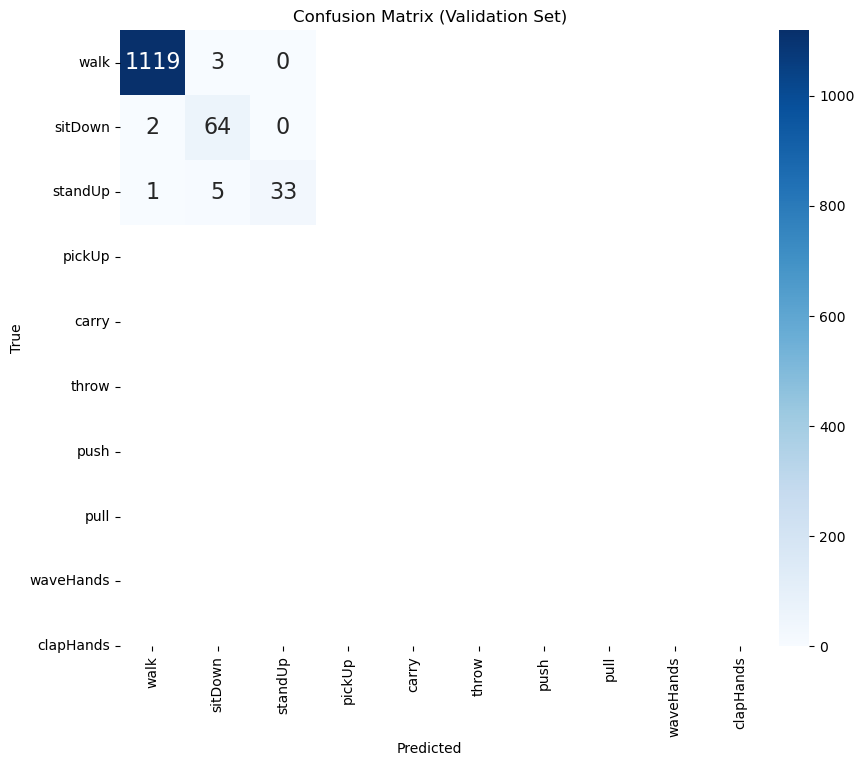


Validation Set Metrics:
              precision    recall  f1-score   support

        walk       1.00      1.00      1.00      1122
     sitDown       0.89      0.97      0.93        66
     standUp       1.00      0.85      0.92        39
      pickUp       0.00      0.00      0.00         0
       carry       0.00      0.00      0.00         0
       throw       0.00      0.00      0.00         0
        push       0.00      0.00      0.00         0
        pull       0.00      0.00      0.00         0
   waveHands       0.00      0.00      0.00         0
   clapHands       0.00      0.00      0.00         0

    accuracy                           0.99      1227
   macro avg       0.29      0.28      0.28      1227
weighted avg       0.99      0.99      0.99      1227



C:\Users\hp\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\hp\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\hp\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\hp\anaconda3\Lib\site-packages\sklearn\me

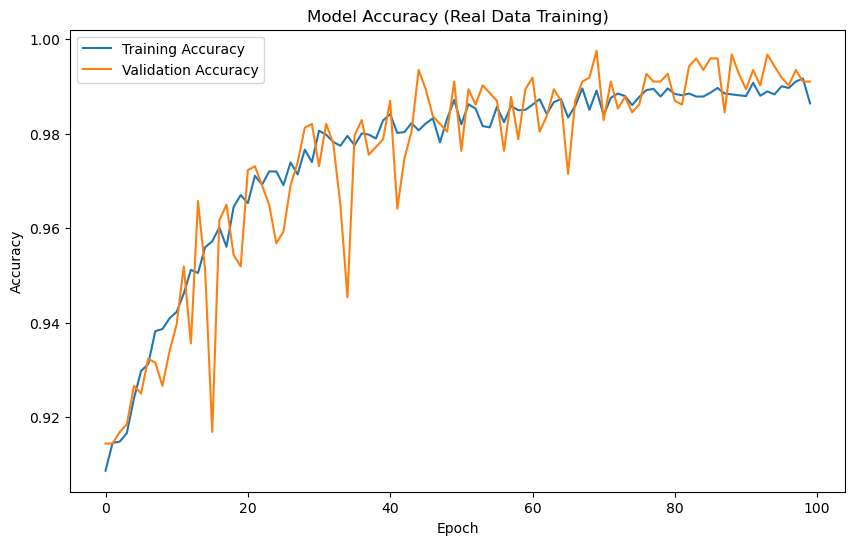


Evaluating classifier on 20% reconstructed data for right_arm
Reconstructed test files for right_arm: ['joints_s01_e01_right_arm_reconstructed.txt', 'joints_s09_e02_right_arm_reconstructed.txt', 'joints_s08_e02_right_arm_reconstructed.txt', 'joints_s01_e02_right_arm_reconstructed.txt', 'joints_s05_e01_right_arm_reconstructed.txt', 'joints_s03_e02_right_arm_reconstructed.txt', 'joints_s06_e02_right_arm_reconstructed.txt', 'joints_s02_e02_right_arm_reconstructed.txt', 'joints_s10_e01_right_arm_reconstructed.txt', 'joints_s09_e01_right_arm_reconstructed.txt', 'joints_s07_e02_right_arm_reconstructed.txt', 'joints_s02_e01_right_arm_reconstructed.txt', 'joints_s05_e02_right_arm_reconstructed.txt', 'joints_s10_e02_right_arm_reconstructed.txt', 'joints_s03_e01_right_arm_reconstructed.txt', 'joints_s07_e01_right_arm_reconstructed.txt']
Invalid range for s01_e01: sitDown, 572, 686
Invalid range for s01_e01: standUp, 704, 752
Invalid range for s01_e01: pickUp, 822, 954
Invalid range for s01_e01:

C:\Users\hp\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Saved confusion matrix for right_arm to C:\Users\hp\Desktop\CRNN-Test\confusion_matrix_right_arm.png


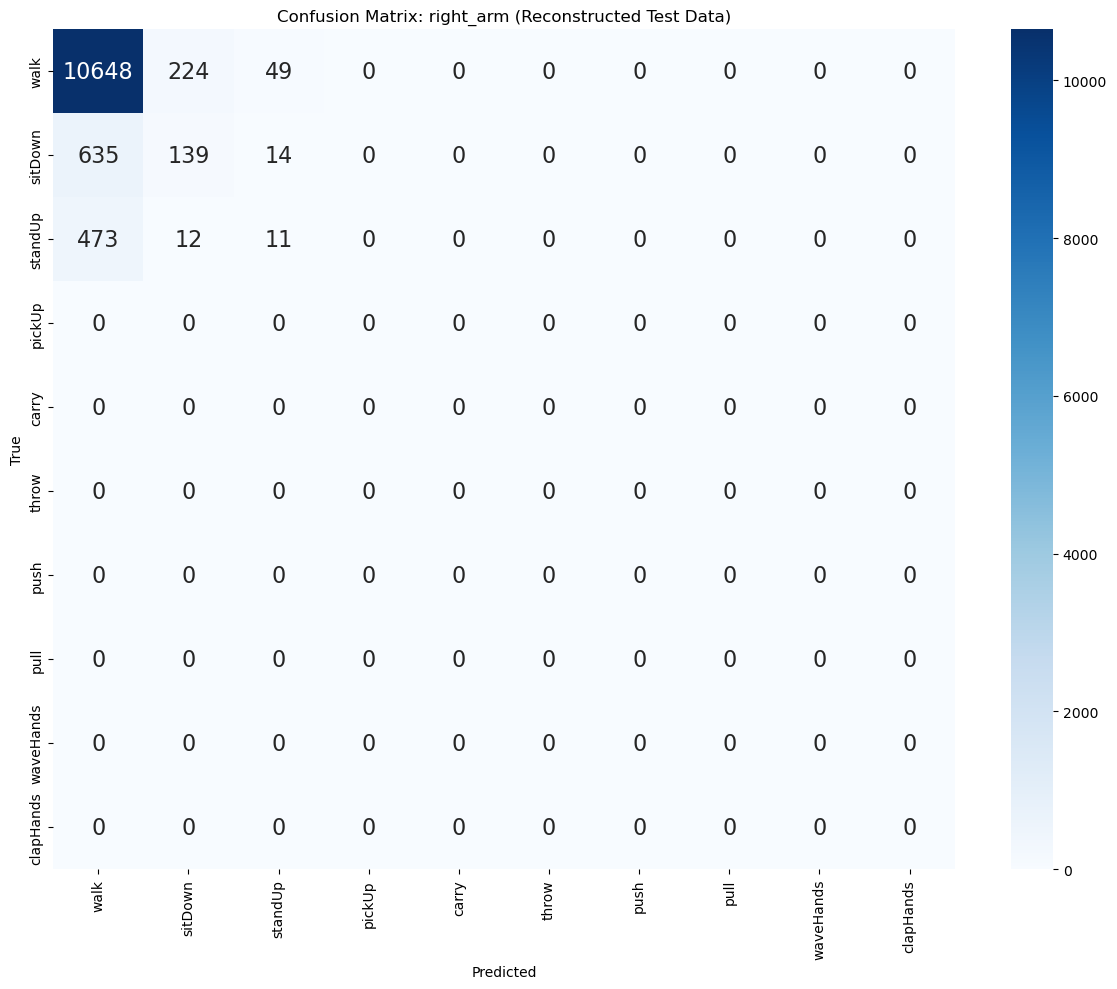


Metrics for right_arm:
Overall Accuracy: 0.8847
Balanced Accuracy: 0.3912
Weighted Accuracy (by support): 0.8847

Evaluating classifier on 20% reconstructed data for left_arm
Reconstructed test files for left_arm: ['joints_s01_e01_left_arm_reconstructed.txt', 'joints_s09_e02_left_arm_reconstructed.txt', 'joints_s08_e02_left_arm_reconstructed.txt', 'joints_s01_e02_left_arm_reconstructed.txt', 'joints_s05_e01_left_arm_reconstructed.txt', 'joints_s03_e02_left_arm_reconstructed.txt', 'joints_s06_e02_left_arm_reconstructed.txt', 'joints_s02_e02_left_arm_reconstructed.txt', 'joints_s10_e01_left_arm_reconstructed.txt', 'joints_s09_e01_left_arm_reconstructed.txt', 'joints_s07_e02_left_arm_reconstructed.txt', 'joints_s02_e01_left_arm_reconstructed.txt', 'joints_s05_e02_left_arm_reconstructed.txt', 'joints_s10_e02_left_arm_reconstructed.txt', 'joints_s03_e01_left_arm_reconstructed.txt', 'joints_s07_e01_left_arm_reconstructed.txt']
Invalid range for s01_e01: sitDown, 572, 686
Invalid range for s

C:\Users\hp\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Saved confusion matrix for left_arm to C:\Users\hp\Desktop\CRNN-Test\confusion_matrix_left_arm.png


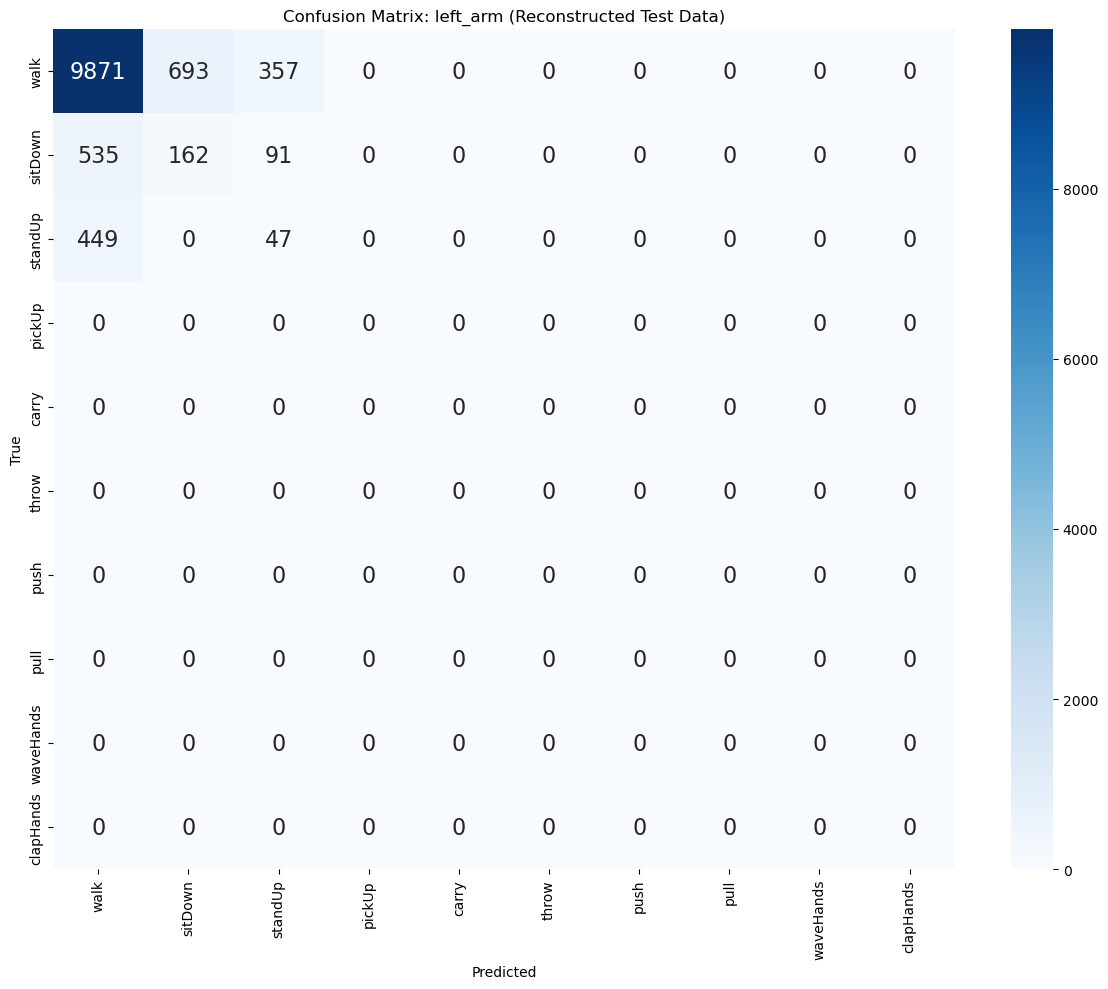


Metrics for left_arm:
Overall Accuracy: 0.8259
Balanced Accuracy: 0.4014
Weighted Accuracy (by support): 0.8259

Evaluating classifier on 20% reconstructed data for right_leg
Reconstructed test files for right_leg: ['joints_s01_e01_right_leg_reconstructed.txt', 'joints_s09_e02_right_leg_reconstructed.txt', 'joints_s08_e02_right_leg_reconstructed.txt', 'joints_s01_e02_right_leg_reconstructed.txt', 'joints_s05_e01_right_leg_reconstructed.txt', 'joints_s03_e02_right_leg_reconstructed.txt', 'joints_s06_e02_right_leg_reconstructed.txt', 'joints_s02_e02_right_leg_reconstructed.txt', 'joints_s10_e01_right_leg_reconstructed.txt', 'joints_s09_e01_right_leg_reconstructed.txt', 'joints_s07_e02_right_leg_reconstructed.txt', 'joints_s02_e01_right_leg_reconstructed.txt', 'joints_s05_e02_right_leg_reconstructed.txt', 'joints_s10_e02_right_leg_reconstructed.txt', 'joints_s03_e01_right_leg_reconstructed.txt', 'joints_s07_e01_right_leg_reconstructed.txt']
Invalid range for s01_e01: sitDown, 572, 686
In

C:\Users\hp\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Saved confusion matrix for right_leg to C:\Users\hp\Desktop\CRNN-Test\confusion_matrix_right_leg.png


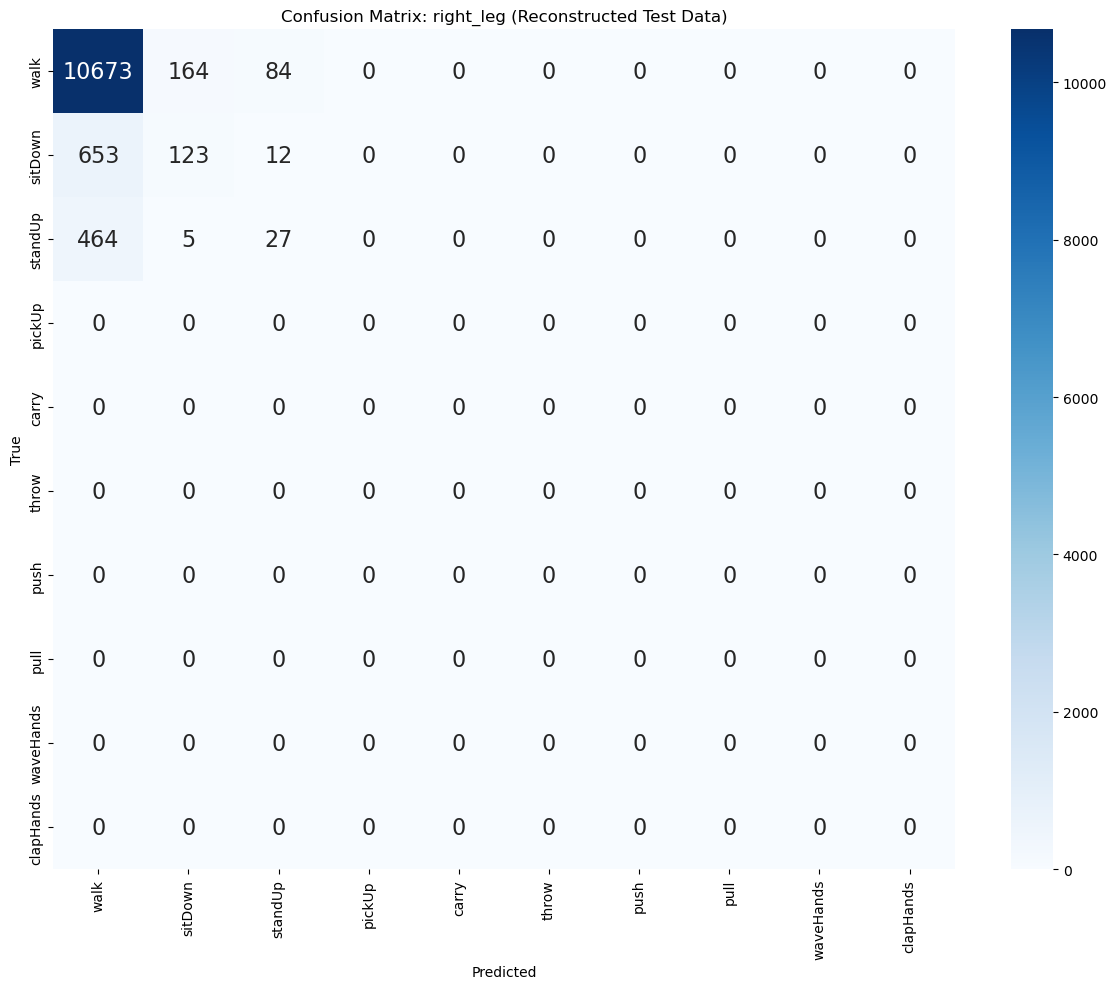


Metrics for right_leg:
Overall Accuracy: 0.8868
Balanced Accuracy: 0.3959
Weighted Accuracy (by support): 0.8868

Evaluating classifier on 20% reconstructed data for left_leg
Reconstructed test files for left_leg: ['joints_s01_e01_left_leg_reconstructed.txt', 'joints_s09_e02_left_leg_reconstructed.txt', 'joints_s08_e02_left_leg_reconstructed.txt', 'joints_s01_e02_left_leg_reconstructed.txt', 'joints_s05_e01_left_leg_reconstructed.txt', 'joints_s03_e02_left_leg_reconstructed.txt', 'joints_s06_e02_left_leg_reconstructed.txt', 'joints_s02_e02_left_leg_reconstructed.txt', 'joints_s10_e01_left_leg_reconstructed.txt', 'joints_s09_e01_left_leg_reconstructed.txt', 'joints_s07_e02_left_leg_reconstructed.txt', 'joints_s02_e01_left_leg_reconstructed.txt', 'joints_s05_e02_left_leg_reconstructed.txt', 'joints_s10_e02_left_leg_reconstructed.txt', 'joints_s03_e01_left_leg_reconstructed.txt', 'joints_s07_e01_left_leg_reconstructed.txt']
Invalid range for s01_e01: sitDown, 572, 686
Invalid range for s

C:\Users\hp\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Saved confusion matrix for left_leg to C:\Users\hp\Desktop\CRNN-Test\confusion_matrix_left_leg.png


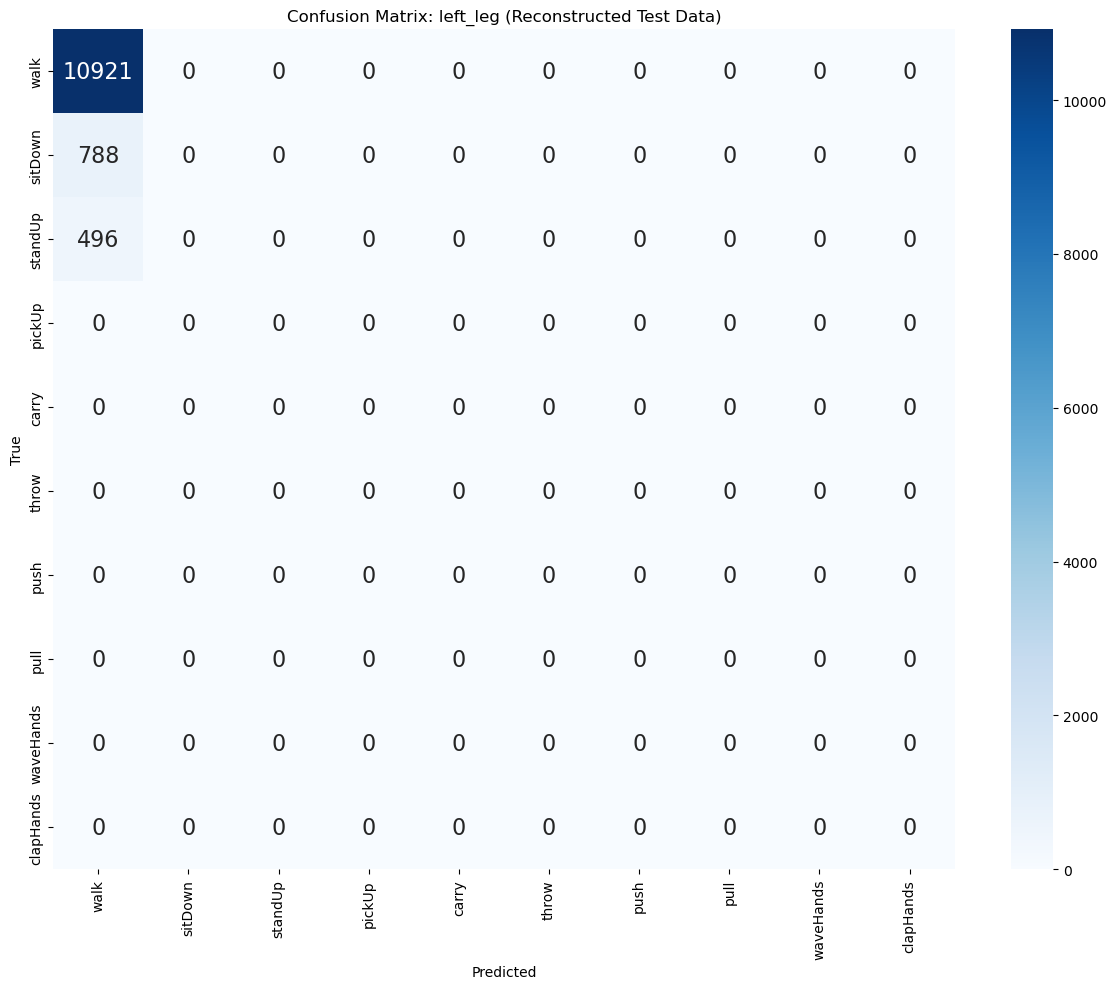


Metrics for left_leg:
Overall Accuracy: 0.8948
Balanced Accuracy: 0.3333
Weighted Accuracy (by support): 0.8948

Evaluating classifier on 20% reconstructed data for right_arm_leg
Reconstructed test files for right_arm_leg: ['joints_s01_e01_right_arm_leg_reconstructed.txt', 'joints_s09_e02_right_arm_leg_reconstructed.txt', 'joints_s08_e02_right_arm_leg_reconstructed.txt', 'joints_s01_e02_right_arm_leg_reconstructed.txt', 'joints_s05_e01_right_arm_leg_reconstructed.txt', 'joints_s03_e02_right_arm_leg_reconstructed.txt', 'joints_s06_e02_right_arm_leg_reconstructed.txt', 'joints_s02_e02_right_arm_leg_reconstructed.txt', 'joints_s10_e01_right_arm_leg_reconstructed.txt', 'joints_s09_e01_right_arm_leg_reconstructed.txt', 'joints_s07_e02_right_arm_leg_reconstructed.txt', 'joints_s02_e01_right_arm_leg_reconstructed.txt', 'joints_s05_e02_right_arm_leg_reconstructed.txt', 'joints_s10_e02_right_arm_leg_reconstructed.txt', 'joints_s03_e01_right_arm_leg_reconstructed.txt', 'joints_s07_e01_right_arm

C:\Users\hp\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Saved confusion matrix for right_arm_leg to C:\Users\hp\Desktop\CRNN-Test\confusion_matrix_right_arm_leg.png


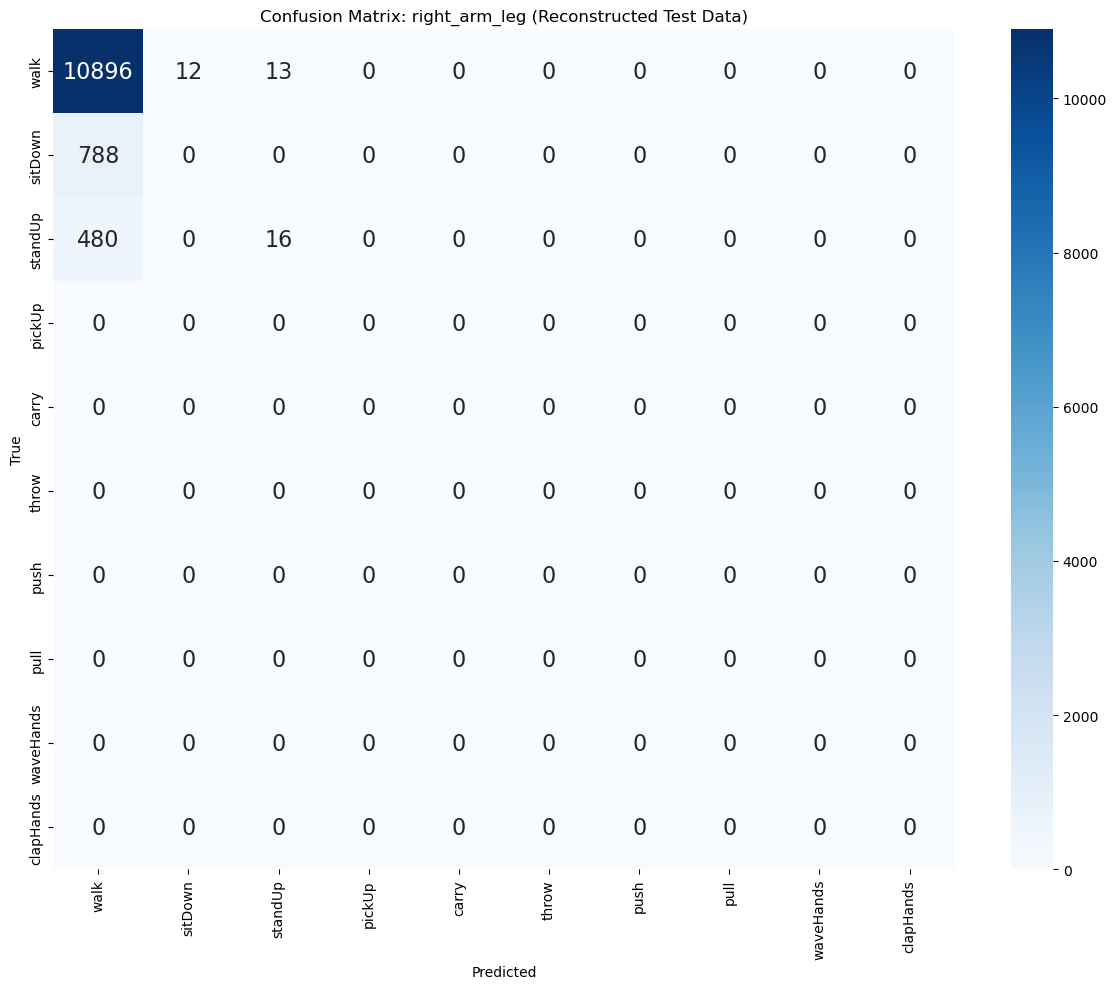


Metrics for right_arm_leg:
Overall Accuracy: 0.8941
Balanced Accuracy: 0.3433
Weighted Accuracy (by support): 0.8941

Evaluating classifier on 20% reconstructed data for left_arm_leg
Reconstructed test files for left_arm_leg: ['joints_s01_e01_left_arm_leg_reconstructed.txt', 'joints_s09_e02_left_arm_leg_reconstructed.txt', 'joints_s08_e02_left_arm_leg_reconstructed.txt', 'joints_s01_e02_left_arm_leg_reconstructed.txt', 'joints_s05_e01_left_arm_leg_reconstructed.txt', 'joints_s03_e02_left_arm_leg_reconstructed.txt', 'joints_s06_e02_left_arm_leg_reconstructed.txt', 'joints_s02_e02_left_arm_leg_reconstructed.txt', 'joints_s10_e01_left_arm_leg_reconstructed.txt', 'joints_s09_e01_left_arm_leg_reconstructed.txt', 'joints_s07_e02_left_arm_leg_reconstructed.txt', 'joints_s02_e01_left_arm_leg_reconstructed.txt', 'joints_s05_e02_left_arm_leg_reconstructed.txt', 'joints_s10_e02_left_arm_leg_reconstructed.txt', 'joints_s03_e01_left_arm_leg_reconstructed.txt', 'joints_s07_e01_left_arm_leg_reconstr

C:\Users\hp\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Saved confusion matrix for left_arm_leg to C:\Users\hp\Desktop\CRNN-Test\confusion_matrix_left_arm_leg.png


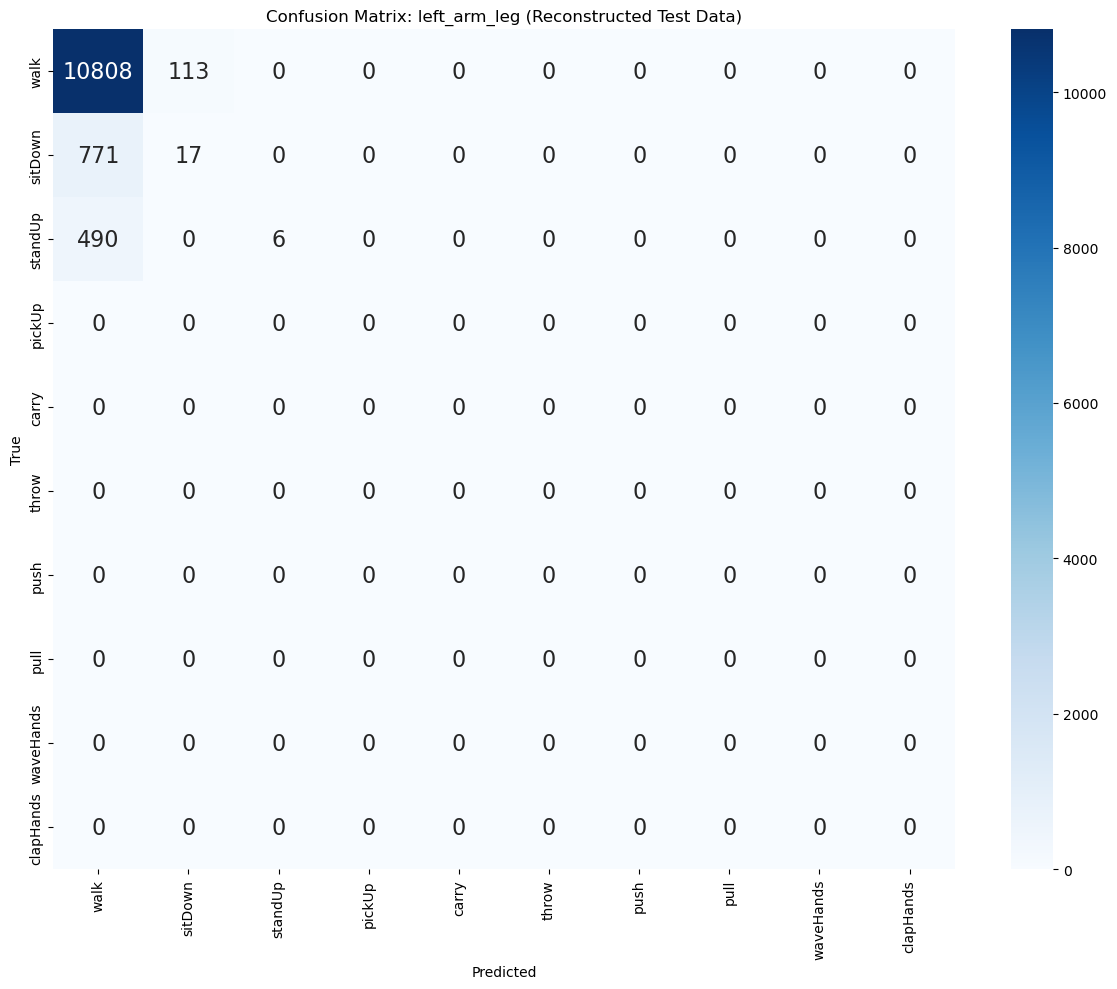


Metrics for left_arm_leg:
Overall Accuracy: 0.8874
Balanced Accuracy: 0.3411
Weighted Accuracy (by support): 0.8874

Evaluating classifier on 20% reconstructed data for both_arms
Reconstructed test files for both_arms: ['joints_s01_e01_both_arms_reconstructed.txt', 'joints_s09_e02_both_arms_reconstructed.txt', 'joints_s08_e02_both_arms_reconstructed.txt', 'joints_s01_e02_both_arms_reconstructed.txt', 'joints_s05_e01_both_arms_reconstructed.txt', 'joints_s03_e02_both_arms_reconstructed.txt', 'joints_s06_e02_both_arms_reconstructed.txt', 'joints_s02_e02_both_arms_reconstructed.txt', 'joints_s10_e01_both_arms_reconstructed.txt', 'joints_s09_e01_both_arms_reconstructed.txt', 'joints_s07_e02_both_arms_reconstructed.txt', 'joints_s02_e01_both_arms_reconstructed.txt', 'joints_s05_e02_both_arms_reconstructed.txt', 'joints_s10_e02_both_arms_reconstructed.txt', 'joints_s03_e01_both_arms_reconstructed.txt', 'joints_s07_e01_both_arms_reconstructed.txt']
Invalid range for s01_e01: sitDown, 572, 68

C:\Users\hp\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Saved confusion matrix for both_arms to C:\Users\hp\Desktop\CRNN-Test\confusion_matrix_both_arms.png


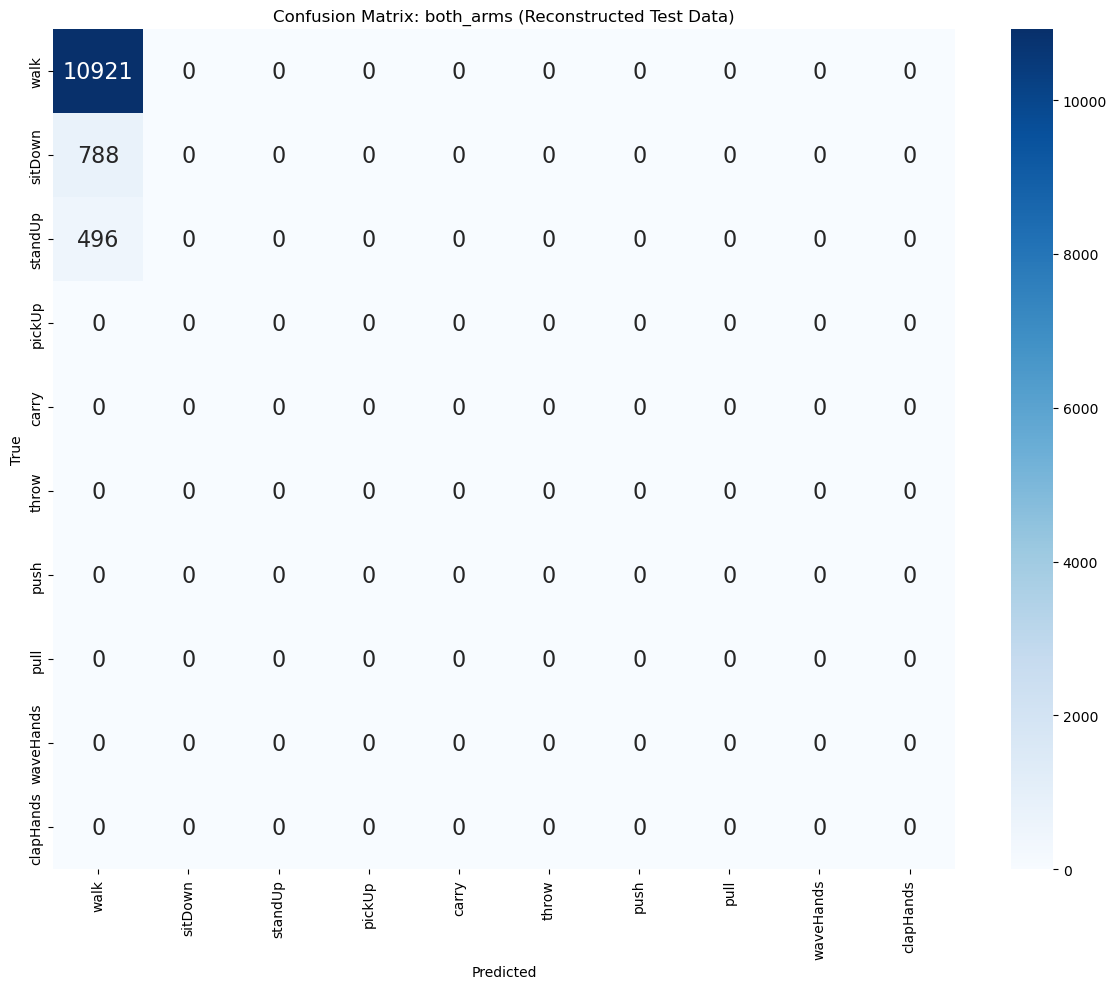


Metrics for both_arms:
Overall Accuracy: 0.8948
Balanced Accuracy: 0.3333
Weighted Accuracy (by support): 0.8948

Evaluating classifier on 20% reconstructed data for both_legs
Reconstructed test files for both_legs: ['joints_s01_e01_both_legs_reconstructed.txt', 'joints_s09_e02_both_legs_reconstructed.txt', 'joints_s08_e02_both_legs_reconstructed.txt', 'joints_s01_e02_both_legs_reconstructed.txt', 'joints_s05_e01_both_legs_reconstructed.txt', 'joints_s03_e02_both_legs_reconstructed.txt', 'joints_s06_e02_both_legs_reconstructed.txt', 'joints_s02_e02_both_legs_reconstructed.txt', 'joints_s10_e01_both_legs_reconstructed.txt', 'joints_s09_e01_both_legs_reconstructed.txt', 'joints_s07_e02_both_legs_reconstructed.txt', 'joints_s02_e01_both_legs_reconstructed.txt', 'joints_s05_e02_both_legs_reconstructed.txt', 'joints_s10_e02_both_legs_reconstructed.txt', 'joints_s03_e01_both_legs_reconstructed.txt', 'joints_s07_e01_both_legs_reconstructed.txt']
Invalid range for s01_e01: sitDown, 572, 686
I

C:\Users\hp\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Saved confusion matrix for both_legs to C:\Users\hp\Desktop\CRNN-Test\confusion_matrix_both_legs.png


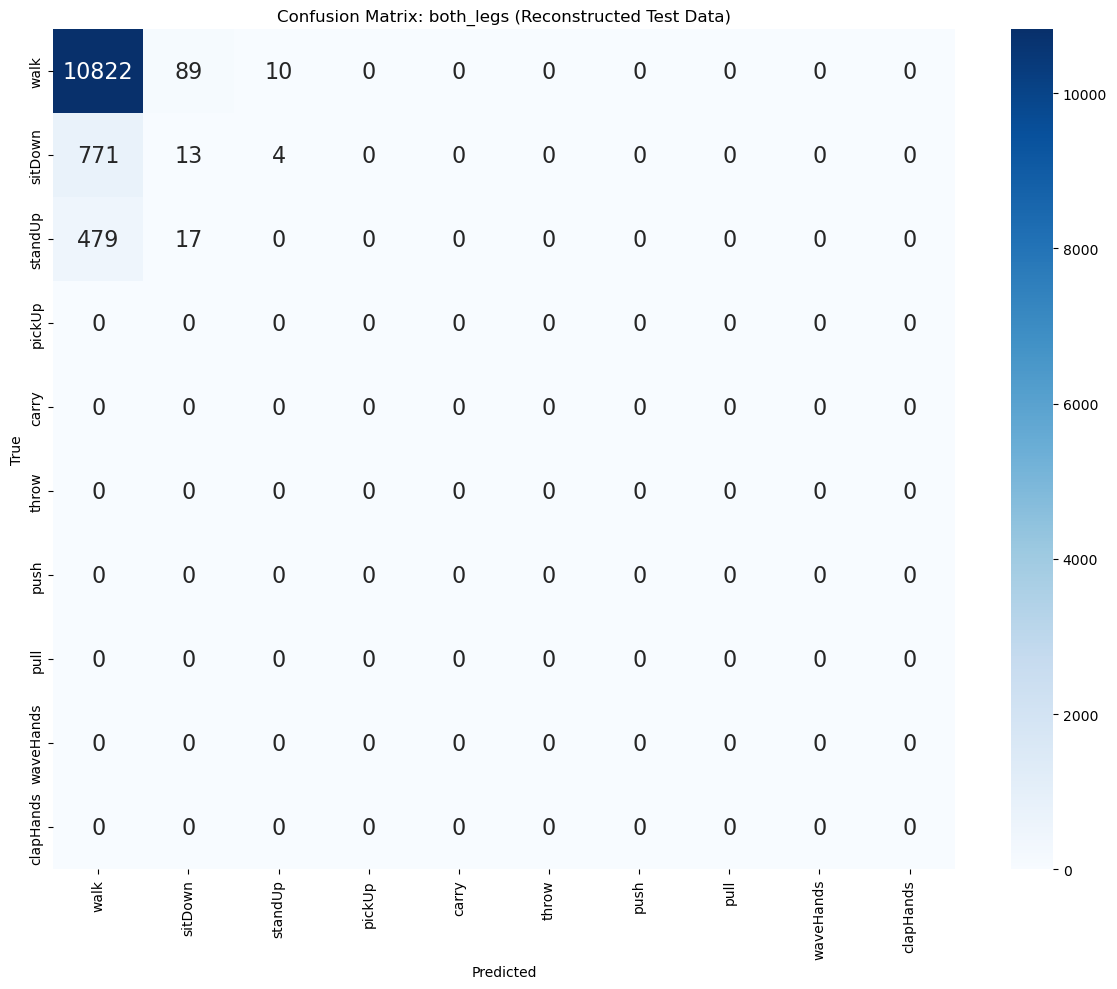


Metrics for both_legs:
Overall Accuracy: 0.8878
Balanced Accuracy: 0.3358
Weighted Accuracy (by support): 0.8878

Merged Evaluation Results for All Cases on 20% Reconstructed Data:
         Case    Action  Class Accuracy  F1 Score
    both_arms     carry          0.0000    0.0000
    both_arms clapHands          0.0000    0.0000
    both_arms    pickUp          0.0000    0.0000
    both_arms      pull          0.0000    0.0000
    both_arms      push          0.0000    0.0000
    both_arms   sitDown          0.0000    0.0000
    both_arms   standUp          0.0000    0.0000
    both_arms     throw          0.0000    0.0000
    both_arms      walk          1.0000    0.9445
    both_arms waveHands          0.0000    0.0000
    both_legs     carry          0.0000    0.0000
    both_legs clapHands          0.0000    0.0000
    both_legs    pickUp          0.0000    0.0000
    both_legs      pull          0.0000    0.0000
    both_legs      push          0.0000    0.0000
    both_legs   si

In [2]:
#Classification of activities for CRNN based reconstructed skeletons

import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout, Add
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, f1_score, accuracy_score, balanced_accuracy_score
from sklearn.metrics import classification_report
import pandas as pd

# --------------- Action Labels ---------------
action_ranges = {
    "s01_e01": [("walk", 252, 390), ("sitDown", 572, 686), ("standUp", 704, 752),
                ("pickUp", 822, 954), ("carry", 1016, 1242), ("throw", 1434, 1488),
                ("push", 1686, 1748), ("pull", 1640, 1686), ("waveHands", 1834, 2064),
                ("clapHands", 2110, 2228)],
    "s01_e02": [("walk", 154, 192), ("sitDown", 530, 628), ("standUp", 640, 720),
                ("pickUp", 1202, 1356), ("carry", 1364, 1520), ("throw", 2246, 2294),
                ("push", 2752, 2792), ("pull", 2820, 2858), ("waveHands", 2984, 3204),
                ("clapHands", 3250, 3448)],
    "s02_e01": [("walk", 266, 368), ("sitDown", 672, 788), ("standUp", 818, 910),
                ("pickUp", 1262, 1386), ("carry", 1424, 1780), ("throw", 2040, 2086),
                ("push", 2340, 2376), ("pull", 2488, 2550), ("waveHands", 2668, 2830),
                ("clapHands", 3198, 3324)],
    "s02_e02": [("walk", 40, 208), ("sitDown", 468, 602), ("standUp", 620, 722),
                ("pickUp", 894, 1038), ("carry", 1340, 1480), ("throw", 1966, 2014),
                ("push", 2194, 2230), ("pull", 2314, 2358), ("waveHands", 2408, 2630),
                ("clapHands", 2690, 2810)],
    "s03_e01": [("walk", 372, 528), ("sitDown", 734, 862), ("standUp", 902, 1000),
                ("pickUp", 1118, 1284), ("carry", 1934, 2168), ("throw", 3226, 3282),
                ("push", 3556, 3622), ("pull", 3660, 3730), ("waveHands", 3806, 3960),
                ("clapHands", 4076, 4184)],
    "s03_e02": [("walk", 122, 254), ("sitDown", 452, 592), ("standUp", 644, 724),
                ("pickUp", 848, 1018), ("carry", 1078, 1192), ("throw", 1638, 1690),
                ("push", 1866, 1896), ("pull", 1928, 2008), ("waveHands", 2054, 2208),
                ("clapHands", 2324, 2460)],
    "s04_e01": [("walk", 348, 496), ("sitDown", 788, 864), ("standUp", 954, 1056),
                ("pickUp", 1190, 1326), ("carry", 1580, 1882), ("throw", 2306, 2350),
                ("push", 2532, 2572), ("pull", 2644, 2686), ("waveHands", 2790, 2968),
                ("clapHands", 3064, 3146)],
    "s04_e02": [("walk", 420, 546), ("sitDown", 1046, 1144), ("standUp", 1352, 1414),
                ("pickUp", 1682, 1820), ("carry", 1868, 2122), ("throw", 2564, 2608),
                ("push", 2760, 2792), ("pull", 2866, 2910), ("waveHands", 3070, 3260),
                ("clapHands", 3448, 3622)],
    "s05_e01": [("walk", 708, 888), ("sitDown", 1140, 1238), ("standUp", 1294, 1394),
                ("pickUp", 1482, 1676), ("carry", 1736, 2064), ("throw", 3104, 3176),
                ("push", 3596, 3632), ("pull", 3706, 3770), ("waveHands", 3946, 4352),
                ("clapHands", 4522, 4734)],
    "s05_e02": [("walk", 212, 376), ("sitDown", 634, 756), ("standUp", 788, 862),
                ("pickUp", 974, 1180), ("carry", 1266, 1540), ("throw", 1752, 1828),
                ("push", 2172, 2230), ("pull", 2104, 2156), ("waveHands", 2504, 2784),
                ("clapHands", 2798, 2900)],
    "s06_e01": [("walk", 1230, 1366), ("sitDown", 1564, 1644), ("standUp", 1678, 1758),
                ("pickUp", 1862, 1948), ("carry", 1966, 2098), ("throw", 2392, 2414),
                ("push", 2672, 2698), ("pull", 2790, 2824), ("waveHands", 3046, 3216),
                ("clapHands", 3290, 3444)],
    "s06_e02": [("walk", 294, 426), ("sitDown", 710, 818), ("standUp", 856, 956),
                ("pickUp", 1088, 1174), ("carry", 2031, 2202), ("throw", 2518, 2562),
                ("push", 2702, 2726), ("pull", 2770, 2808), ("waveHands", 2952, 3060),
                ("clapHands", 3096, 3188)],
    "s07_e01": [("walk", 130, 252), ("sitDown", 1038, 1186), ("standUp", 1256, 1372),
                ("pickUp", 1450, 1602), ("carry", 1602, 1758), ("throw", 2534, 2614),
                ("push", 3290, 3350), ("pull", 3350, 3522), ("waveHands", 3666, 3902),
                ("clapHands", 3990, 4128)],
    "s07_e02": [("walk", 552, 638), ("sitDown", 880, 1014), ("standUp", 1014, 1146),
                ("pickUp", 1228, 1352), ("carry", 1352, 1518), ("throw", 1990, 2058),
                ("push", 2434, 2496), ("pull", 2496, 2618), ("waveHands", 2672, 2982),
                ("clapHands", 3042, 3152)],
    "s08_e01": [("walk", 446, 534), ("sitDown", 714, 812), ("standUp", 836, 900),
                ("pickUp", 1026, 1144), ("carry", 1228, 1588), ("throw", 1880, 1916),
                ("push", 2236, 2268), ("pull", 2334, 2398), ("waveHands", 2598, 2772),
                ("clapHands", 2794, 2892)],
    "s08_e02": [("walk", 138, 246), ("sitDown", 610, 716), ("standUp", 770, 878),
                ("pickUp", 1126, 1200), ("carry", 1364, 1650), ("throw", 1826, 1878),
                ("push", 2030, 2078), ("pull", 2126, 2204), ("waveHands", 2280, 2506),
                ("clapHands", 2574, 2650)],
    "s09_e01": [("walk", 404, 544), ("sitDown", 1080, 1196), ("standUp", 1212, 1290),
                ("pickUp", 1422, 1538), ("carry", 1668, 1970), ("throw", 2688, 2728),
                ("push", 3266, 3316), ("pull", 3316, 3390), ("waveHands", 3576, 3762),
                ("clapHands", 3992, 4118)],
    "s09_e02": [("walk", 482, 610), ("sitDown", 1026, 1158), ("standUp", 1206, 1310),
                ("pickUp", 1546, 1678), ("carry", 1714, 2120), ("throw", 2468, 2522),
                ("push", 2696, 2760), ("pull", 2770, 2838), ("waveHands", 4708, 4872),
                ("clapHands", 4904, 4964)],
    "s10_e01": [("walk", 100, 272), ("sitDown", 562, 730), ("standUp", 730, 862),
                ("pickUp", 924, 1150), ("carry", 1394, 1846), ("throw", 3304, 3388),
                ("push", 3468, 3524), ("pull", 3524, 3608), ("waveHands", 3962, 4222),
                ("clapHands", 4268, 4336)],
    "s10_e02": [("walk", 96, 220), ("sitDown", 500, 658), ("standUp", 664, 770),
                ("pickUp", 1022, 1232), ("carry", "NaN", "NaN"), ("throw", 1720, 1810),
                ("push", 1944, 1994), ("pull", 1982, 2062), ("waveHands", 2094, 2350),
                ("clapHands", 2454, 2598)]
}

# --------------- Data Utilities ---------------
def load_skeleton_file(file_path):
    data = []
    with open(file_path, 'r') as f:
        for line in f:
            line = line.strip()
            if line.startswith('#') or not line:
                continue
            try:
                parts = list(map(float, line.split()))
                if len(parts) == 61:
                    data.append(parts[1:])
                else:
                    print(f"Warning: Skipping line in {file_path} with incorrect number of values ({len(parts)} != 61)")
            except ValueError as e:
                print(f"Warning: Skipping invalid line in {file_path}: {line} ({str(e)})")
    if not data:
        print(f"Warning: No valid data in {file_path}")
    return np.array(data)

def load_all_skeletons_and_labels(real_dir, rec_dir=None, case=None, train=True):
    all_data = []
    all_labels = []
    action_mapping = {
        0: 'walk', 1: 'sitDown', 2: 'standUp', 3: 'pickUp', 4: 'carry',
        5: 'throw', 6: 'push', 7: 'pull', 8: 'waveHands', 9: 'clapHands'
    }
    
    # Load real data (80% for training, 20% for test file names)
    files = [f for f in os.listdir(real_dir) if f.endswith(".txt")]
    if len(files) != 20:
        print(f"Warning: Expected 20 files in {real_dir}, found {len(files)}")
    
    train_files, test_files = train_test_split(files, train_size=0.8, random_state=42)
    
    # For training, load 80% real data
    if train:
        selected_files = train_files
        print(f"Real training files: {selected_files}")
        for filename in selected_files:
            file_key = filename.replace('joints_', '').replace('.txt', '')
            full_path = os.path.join(real_dir, filename)
            sequence = load_skeleton_file(full_path)
            num_frames = len(sequence)
            
            labels = np.zeros(num_frames, dtype=int)
            if file_key in action_ranges:
                for action, start, end in action_ranges[file_key]:
                    if isinstance(start, str) or isinstance(end, str):
                        continue
                    start, end = int(start), int(end)
                    if start >= 0 and end <= num_frames and start < end:
                        action_id = [k for k, v in action_mapping.items() if v == action][0]
                        labels[start:end] = action_id
                    else:
                        print(f"Invalid range for {file_key}: {action}, {start}, {end}")
            else:
                print(f"No action ranges for {filename}, using default labels.")
            
            all_data.append(sequence)
            all_labels.append(labels)
    
    return all_data, all_labels, action_mapping, test_files

# --------------- Classifier Model ---------------
def build_classifier(T=30, num_features=60, num_classes=10):
    inp = Input(shape=(T, num_features))
    x = inp
    x_res = x
    x = Dense(60, activation='relu')(x)
    x = Add()([x, x_res])
    x = LSTM(225, return_sequences=True)(x)
    x = Dropout(0.3)(x)
    x = LSTM(256, return_sequences=False)(x)
    x = Dropout(0.3)(x)
    out = Dense(num_classes, activation='softmax')(x)
    return Model(inp, out, name="ActionClassifier")

# --------------- Training ---------------
def train_classifier(sequences, labels, action_mapping, T=30, epochs=100, batch_size=32):
    # Normalize
    all_frames = np.concatenate(sequences)
    min_vals = all_frames.min(axis=0)
    max_vals = all_frames.max(axis=0)
    ranges = max_vals - min_vals + 1e-6
    
    # Add noise for augmentation
    def add_noise(sequence, noise_level=0.01):
        noise = np.random.normal(0, noise_level, sequence.shape)
        return sequence + noise
    
    # Apply normalization and noise
    sequences = [add_noise((seq - min_vals) / ranges) for seq in sequences]

    # Prepare sequences of T frames
    X, y = [], []
    for seq, seq_labels in zip(sequences, labels):
        for i in range(0, len(seq) - T + 1):
            X.append(seq[i:i+T])
            y.append(seq_labels[i+T-1])
    X = np.array(X)
    y = np.array(y)

    # Use 10% validation data
    x_train, x_val, y_train, y_val = train_test_split(X, y, test_size=0.1, random_state=42, stratify=y)

    classifier = build_classifier(T=T, num_features=60, num_classes=len(np.unique(y)))
    classifier.compile(optimizer=Adam(1e-4), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

    history = classifier.fit(x_train, y_train, validation_data=(x_val, y_val), epochs=epochs, batch_size=batch_size, verbose=1)

    # Confusion Matrix for validation set
    y_pred = classifier.predict(x_val)
    y_pred_classes = np.argmax(y_pred, axis=1)
    cm = confusion_matrix(y_val, y_pred_classes)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', annot_kws={"size": 16}, xticklabels=list(action_mapping.values()), yticklabels=list(action_mapping.values()))

    plt.title('Confusion Matrix (Validation Set)')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

    # Print detailed metrics
    print("\nValidation Set Metrics:")
    print(classification_report(y_val, y_pred_classes, target_names=list(action_mapping.values()), labels=list(range(10))))

    return classifier, min_vals, ranges, history

# --------------- Prediction for Reconstructed Cases ---------------
def evaluate_reconstructed_cases(classifier, rec_dir, min_vals, ranges, action_mapping, case, T=30):
    true_labels = []
    pred_labels = []
    
    # Load reconstructed test data
    case_path = os.path.join(rec_dir, case)
    if not os.path.exists(case_path):
        print(f"Error: Directory {case_path} does not exist, skipping.")
        return None
    
    # Get all files in the case directory
    all_files = [f for f in os.listdir(case_path) if f.endswith(f"{case}_reconstructed.txt")]
    if not all_files:
        print(f"Error: No reconstructed files found in {case_path}, skipping.")
        return None
    
    # Select 20% of the files
    test_files = train_test_split(all_files, train_size=0.2, random_state=42)[1]
    print(f"Reconstructed test files for {case}: {test_files}")
    
    for filename in test_files:
        # Extract the base file key (e.g., s01_e01) by removing the case-specific suffix
        file_key = filename.replace('joints_', '').replace(f'_{case}_reconstructed.txt', '')
        full_path = os.path.join(case_path, filename)
        
        sequence = load_skeleton_file(full_path)
        num_frames = len(sequence)
        if num_frames < T:
            print(f"Warning: Sequence {filename} has {num_frames} frames, less than T={T}, skipping.")
            continue
        
        # Generate labels
        labels = np.zeros(num_frames, dtype=int)
        if file_key in action_ranges:
            for action, start, end in action_ranges[file_key]:
                if isinstance(start, str) or isinstance(end, str):
                    continue
                start, end = int(start), int(end)
                if start >= 0 and end <= num_frames and start < end:
                    action_id = [k for k, v in action_mapping.items() if v == action][0]
                    labels[start:end] = action_id
                else:
                    print(f"Invalid range for {file_key}: {action}, {start}, {end}")
        else:
            print(f"No action ranges for {filename}, using default labels.")
        
        # Normalize sequence
        sequence = (sequence - min_vals) / ranges
        
        # Process sequence in windows of T frames
        for i in range(0, len(sequence) - T + 1):
            input_seq = sequence[i:i+T]
            input_seq = np.expand_dims(input_seq, axis=0)
            pred = classifier.predict(input_seq, verbose=0)
            pred_class = np.argmax(pred, axis=1)[0]
            true_label = labels[i+T-1]
            true_labels.append(true_label)
            pred_labels.append(pred_class)
    
    if not true_labels:
        print(f"No valid frames for case {case}, skipping.")
        return None
    
    # Compute metrics
    f1 = f1_score(true_labels, pred_labels, average=None, labels=list(range(10)))
    cm = confusion_matrix(true_labels, pred_labels, labels=list(range(10)))
    class_counts = np.sum(cm, axis=1)
    per_class_acc = np.zeros(10)
    for i in range(10):
        if class_counts[i] > 0:
            per_class_acc[i] = cm[i, i] / class_counts[i]
        else:
            per_class_acc[i] = 0.0
    class_weights = class_counts / (np.sum(class_counts) + 1e-6)
    weighted_acc = np.sum(per_class_acc * class_weights)
    
    # Plot and show confusion matrix
    plt.figure(figsize=(12, 10))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', annot_kws={"size": 16}, xticklabels=list(action_mapping.values()), yticklabels=list(action_mapping.values()))
    plt.title(f'Confusion Matrix: {case} (Reconstructed Test Data)')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.tight_layout()
    
    # Save confusion matrix
    output_dir = os.path.join(os.path.expanduser("~"), "Desktop", "CRNN-Test")
    os.makedirs(output_dir, exist_ok=True)
    cm_path = os.path.join(output_dir, f'confusion_matrix_{case}.png')
    try:
        plt.savefig(cm_path)
        print(f"Saved confusion matrix for {case} to {cm_path}")
    except Exception as e:
        print(f"Error: Could not save confusion matrix to {cm_path}: {e}")
    
    # Display the confusion matrix
    plt.show()
    
    # Print overall metrics
    overall_acc = accuracy_score(true_labels, pred_labels)
    balanced_acc = balanced_accuracy_score(true_labels, pred_labels)
    print(f"\nMetrics for {case}:")
    print(f"Overall Accuracy: {overall_acc:.4f}")
    print(f"Balanced Accuracy: {balanced_acc:.4f}")
    print(f"Weighted Accuracy (by support): {weighted_acc:.4f}")
    
    # Collect results for table
    results = []
    for i, action in action_mapping.items():
        results.append({
            'Case': case,
            'Action': action,
            'Class Accuracy': round(per_class_acc[i], 4),
            'F1 Score': round(f1[i], 4) if i < len(f1) else 0.0
        })
    
    return results

# --------------- Run Script ---------------
if __name__ == "__main__":
    real_dir = "D:/Thesis/DATA/joints1/joints"
    #rec_dir = os.path.join(os.path.expanduser("~"), "Desktop", "CRNN-Test")
    rec_dir = "E:/PAPER Codes and research/CRNN3"
    action_mapping = {
        0: 'walk', 1: 'sitDown', 2: 'standUp', 3: 'pickUp', 4: 'carry',
        5: 'throw', 6: 'push', 7: 'pull', 8: 'waveHands', 9: 'clapHands'
    }
    cases = [
        "right_arm", "left_arm", "right_leg", "left_leg",
        "right_arm_leg", "left_arm_leg", "both_arms", "both_legs"
    ]

    # Load training data (80% real data) and get test file names
    train_data, train_labels, action_mapping, test_files = load_all_skeletons_and_labels(real_dir, train=True)
    
    # Train classifier on 80% real data
    print("\nTraining classifier with 80% real data")
    classifier, min_vals, ranges, history = train_classifier(train_data, train_labels, action_mapping)

    # Plot training history
    plt.figure(figsize=(10, 6))
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Model Accuracy (Real Data Training)')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.show()

    all_results = []

    # Evaluate on 20% reconstructed data for each case
    for case in cases:
        print(f"\nEvaluating classifier on 20% reconstructed data for {case}")
        case_results = evaluate_reconstructed_cases(classifier, rec_dir, min_vals, ranges, action_mapping, case)
        if case_results is not None:
            all_results.extend(case_results)

    # Create and print merged results table
    results_table = pd.DataFrame(all_results)
    results_table = results_table.sort_values(by=['Case', 'Action']).reset_index(drop=True)
    print("\nMerged Evaluation Results for All Cases on 20% Reconstructed Data:")
    print(results_table.to_string(index=False))
    
    # Save results table to CSV with error handling
    output_dir = os.path.join(os.path.expanduser("~"), "Desktop", "CRNN-Test")
    os.makedirs(output_dir, exist_ok=True)
    results_path = os.path.join(output_dir, 'results_table.csv')
    try:
        results_table.to_csv(results_path, index=False)
        print(f"Saved results table to {results_path}")
    except PermissionError as e:
        print(f"Error: Could not save results table to {results_path} due to permission issues: {e}")
        print("Please ensure the file is not open in another program and you have write permissions for the directory.")
        print("Alternatively, try running the script as an administrator or choose a different output directory.")
    except Exception as e:
        print(f"Error: Failed to save results table to {results_path}: {e}")